In [ ]:
%pip install pandas_datareader
%pip install hmmlearn
%pip install pgmpy

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import os

import networkx as nx
import pylab as plt

from graphviz import Digraph
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Arc
from hmmlearn import hmm
from hmmlearn.hmm import GaussianHMM
from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, FancyArrowPatch
from pandas_datareader import data as web
from pgmpy.estimators import BIC, BDs, BDeu, BayesianEstimator, HillClimbSearch, K2
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.metrics import accuracy_score
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import FancyBboxPatch

### Step 1a

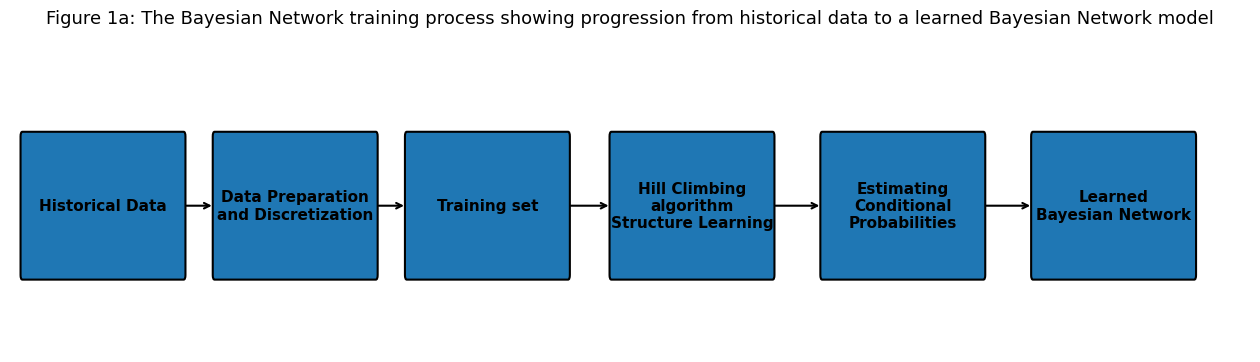

In [ ]:
# Building the image
fig, ax = plt.subplots(figsize=(16, 4))

ax.axis('off')

# parameters
box_width = 2.6
box_height = 0.9
y_pos = 0.5

# X positions
x_positions = [0.2, 3.3, 6.4, 9.7, 13.1, 16.5]

# step labelling
labels = [
    "Historical Data",
    "Data Preparation\nand Discretization",
    "Training set",
    "Hill Climbing\nalgorithm\nStructure Learning",
    "Estimating\nConditional\nProbabilities",
    "Learned\nBayesian Network"
]

boxes = []
for x, label in zip(x_positions, labels):
    box = FancyBboxPatch(
        (x, y_pos),
        box_width,
        box_height,
        boxstyle="round,pad=0.03",
        linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(
        x + box_width / 2,
        y_pos + box_height / 2,
        label,
        ha='center',
        va='center',
        fontsize=11,
        weight='bold'
    )
    boxes.append(box)

# arrow placement
for i in range(len(x_positions) - 1):
    ax.annotate(
        "",
        xy=(x_positions[i + 1], y_pos + box_height / 2),
        xytext=(x_positions[i] + box_width, y_pos + box_height / 2),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

ax.set_xlim(0, 20)
ax.set_ylim(0, 2)

plt.title(
    "Figure 1a: The Bayesian Network training process showing progression from historical data to a learned Bayesian Network model",
    fontsize=13,
    pad=15
)

plt.show()


In [ ]:
dates = pd.date_range(start='2007-01-01', end='2025-12-31', freq='M')
n_obs = len(dates)
# Simulate crude oil prices with regime patterns
# Bull, Bear, Stagnant regimes
t = np.arange(n_obs)
regime_changes = np.random.choice([0, 1, 2], size=n_obs, p=[0.4, 0.3, 0.3])
# Base price pattern
base_price = 60
price = np.zeros(n_obs)
price[0] = base_price
for i in range(1, n_obs):
    if regime_changes[i] == 0:  # Bear
        ret = np.random.normal(-0.02, 0.08)
    elif regime_changes[i] == 1:  # Stagnant
        ret = np.random.normal(0.005, 0.04)
    else:  # Bull
        ret = np.random.normal(0.03, 0.06)
    price[i] = price[i-1] * (1 + ret)
# Add trend and seasonality
price = price + 20 * np.sin(2 * np.pi * t / 12) + t * 0.1
# Create dataframe
data_sample = pd.DataFrame({
    'DATE': dates,
    'CRUDE Oil Prices (US)': price,
    'Global Economic Activity Index': np.cumsum(np.random.randn(n_obs) * 10),
    'VIX Index': np.abs(np.random.randn(n_obs) * 10 + 20)
})
data_sample.set_index('DATE', inplace=True)



total_len = len(data_sample)
train_end = int(total_len * 0.7)
val_end = int(total_len * 0.85)
train_data = data_sample.iloc[:train_end]
val_data = data_sample.iloc[train_end:val_end]
test_data = data_sample.iloc[val_end:]

# Step 2

**Data Allocation and Comparison**

#### Diagram

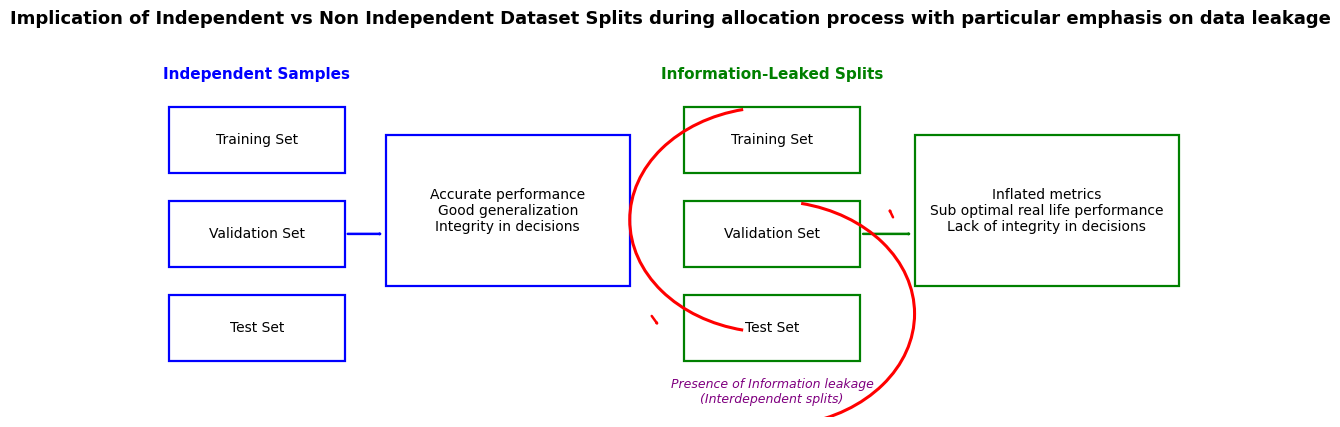

In [ ]:
# Diagram
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

BOX_EDGE = 1.6
ARROW_W = 1.8

def draw_box(x, y, w, h, text, edge_color):
    box = Rectangle(
        (x, y), w, h,
        linewidth=BOX_EDGE,
        edgecolor=edge_color,
        facecolor="none"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=10
    )

# Non leakage
ax.text(
    1.9, 3.6,
    "Independent Samples",
    fontsize=11,
    weight="bold",
    color="blue",
    ha="center"
)

draw_box(0.6, 2.6, 2.6, 0.7, "Training Set", "blue")
draw_box(0.6, 1.6, 2.6, 0.7, "Validation Set", "blue")
draw_box(0.6, 0.6, 2.6, 0.7, "Test Set", "blue")

draw_box(
    3.8, 1.4, 3.6, 1.6,
    "Accurate performance\n"
    "Good generalization\n"
    "Integrity in decisions",
    "blue"
)

ax.add_patch(
    FancyArrowPatch(
        (3.2, 1.95), (3.8, 1.95),
        arrowstyle="->",
        linewidth=ARROW_W,
        color="blue"
    )
)

# Leakages
ax.text(
    9.5, 3.6,
    "Information-Leaked Splits",
    fontsize=11,
    weight="bold",
    color="green",
    ha="center"
)

draw_box(8.2, 2.6, 2.6, 0.7, "Training Set", "green")
draw_box(8.2, 1.6, 2.6, 0.7, "Validation Set", "green")
draw_box(8.2, 0.6, 2.6, 0.7, "Test Set", "green")

draw_box(
    11.6, 1.4, 3.9, 1.6,
    "Inflated metrics\n"
    "Sub optimal real life performance\n"
    "Lack of integrity in decisions",
    "green"
)

ax.add_patch(
    FancyArrowPatch(
        (10.8, 1.95), (11.6, 1.95),
        arrowstyle="->",
        linewidth=ARROW_W,
        color="green"
    )
)

# loops

arc_tv = Arc(
    (9.5, 2.1),
    width=4.2,
    height=2.4,
    theta1=110,
    theta2=250,
    linewidth=2.2,
    color="red"
)
ax.add_patch(arc_tv)

ax.add_patch(
    FancyArrowPatch(
        (11.3, 2.1), (11.2, 2.25),
        arrowstyle="->",
        linewidth=1.8,
        color="red"
    )
)

# Validation ↔ Test leakage
arc_vt = Arc(
    (9.5, 1.1),
    width=4.2,
    height=2.4,
    theta1=290,
    theta2=70,
    linewidth=2.2,
    color="red"
)
ax.add_patch(arc_vt)

ax.add_patch(
    FancyArrowPatch(
        (7.7, 1.1), (7.85, 0.95),
        arrowstyle="->",
        linewidth=1.8,
        color="red"
    )
)

# leakahe highlight
ax.text(
    9.5, 0.15,
    "Presence of Information leakage\n(Interdependent splits)",
    ha="center",
    fontsize=9,
    color="purple",
    style="italic"
)

# Print
ax.set_xlim(0, 16)
ax.set_ylim(0, 4.1)

ax.set_title(
    "Implication of Independent vs Non Independent Dataset Splits during allocation process with particular emphasis on data leakage",
    fontsize=13,
    weight="bold"
)

plt.show()


### Load data already explained in GWP1

In [ ]:
start_date = "2007-01-01"
end_date = "2025-12-31"

In [ ]:
def download_fred_data(data_dict, start_date, end_date):
    series_ids = list(data_dict.values())
    series_id_to_name = {v: k for k, v in data_dict.items()}
    df = pd.DataFrame()
    try:
        raw_data = web.DataReader(series_ids, 'fred', start=start_date, end=end_date)
        df = raw_data.rename(columns=series_id_to_name)
    except Exception as e:
        print(f"An error occurred while downloading FRED data: {e}")
    return df

def download_yahoo_data(yahoo_series_dict, start_date, end_date):
    df_list = []
    try:
        for name, ticker in yahoo_series_dict.items():
            data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
            if not data.empty:
                df_temp = data[['Close']].rename(columns={'Close': name})
                df_list.append(df_temp)
        if df_list:
            df = pd.concat(df_list, axis=1, join='outer')
            df.columns = df.columns.get_level_values('Price')
        else:
            print("No financial data was downloaded for the specified tickers.")
    except Exception as e:
        print(f"An error occurred while downloading Yahoo Finance data: {e}")
    return df

In [ ]:
# FRED Financial Data
fred_financial_data_map = {
    "CRUDE Oil Prices (US)": "DCOILWTICO",
    "OVX": "OVXCLS",
    # "VIX Index": "VIXCLS",
    "Nasdaq": "NASDAQCOM",
    "10Y_Treasury": "DGS10",
}


# Yahoo Finance Data
yahoo_series = {
    # "Futures": "CL=F",
    "XLE": "XLE",
    "S&P_500": "SPY",
    # "Dow_Jones": "^DJI",
}


# FRED Micro Data
micro_data_map = {
    "US Gasoline Consumption": "CUSR0000SETB01",
    "Global Economic Activity Index": "IGREA",
}

# FRED Macro Data
macro_data_map = {
    "Median Consumer Price Index": "MEDCPIM158SFRBCLE",
    "Industrial Production: Total Index": "INDPRO",
    "Gross Domestic Product": "GDP",
    "USD Dollar Index": "DTWEXAFEGS",
}

In [ ]:
yf_financial_data_df = download_yahoo_data(yahoo_series, start_date, end_date)
fred_financial_data = download_fred_data(fred_financial_data_map, start_date, end_date)
micro_data_df = download_fred_data(micro_data_map, start_date, end_date)
macro_data_df = download_fred_data(macro_data_map, start_date, end_date)

In [ ]:
financial_data_df = pd.concat([fred_financial_data, yf_financial_data_df], axis=1)
combined_data = pd.concat([macro_data_df, micro_data_df, financial_data_df], axis=1)
combined_data_monthly = combined_data.resample('MS').first()

combined_data_monthly_filled = combined_data_monthly.bfill()
combined_data_monthly_filled = combined_data_monthly_filled.ffill()
display(combined_data_monthly_filled.head(100))

,Median Consumer Price Index,Industrial Production: Total Index,Gross Domestic Product,USD Dollar Index,US Gasoline Consumption,Global Economic Activity Index,CRUDE Oil Prices (US),OVX,Nasdaq,10Y_Treasury,XLE,S&P_500
2007-01-01,2.964410,99.8346,14215.651,96.3618,205.361,103.728190,60.77,27.09,2423.16,4.68,15.980396,99.394867
2007-02-01,4.447026,100.7753,14402.082,97.3608,208.351,102.063990,57.35,27.09,2468.38,4.84,16.466188,101.672928
2007-03-01,2.688531,100.9547,14402.082,96.4601,222.804,116.971960,61.97,27.09,2404.21,4.56,16.019936,98.790268
2007-04-01,2.368325,101.6334,14402.082,95.3327,229.338,128.455450,66.03,27.09,2422.26,4.65,17.248453,100.346786
2007-05-01,2.353491,101.7306,14564.117,93.5760,240.407,138.882120,64.43,27.09,2531.53,4.64,18.036215,104.942024
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-01,2.383394,103.7044,18063.529,98.7226,238.491,-54.337536,68.98,37.49,4727.35,2.22,25.739397,169.925735
2015-01-01,1.947530,102.8905,18063.529,102.0577,199.553,-76.189147,52.72,54.25,4726.81,2.12,25.714987,170.589630
2015-02-01,1.954495,102.2335,18279.784,106.1458,206.901,-105.872380,49.25,57.84,4676.69,1.68,25.175016,167.674866
2015-03-01,2.433336,101.8914,18279.784,106.8022,214.684,-99.416683,49.59,54.92,5008.10,2.08,25.372252,176.037125


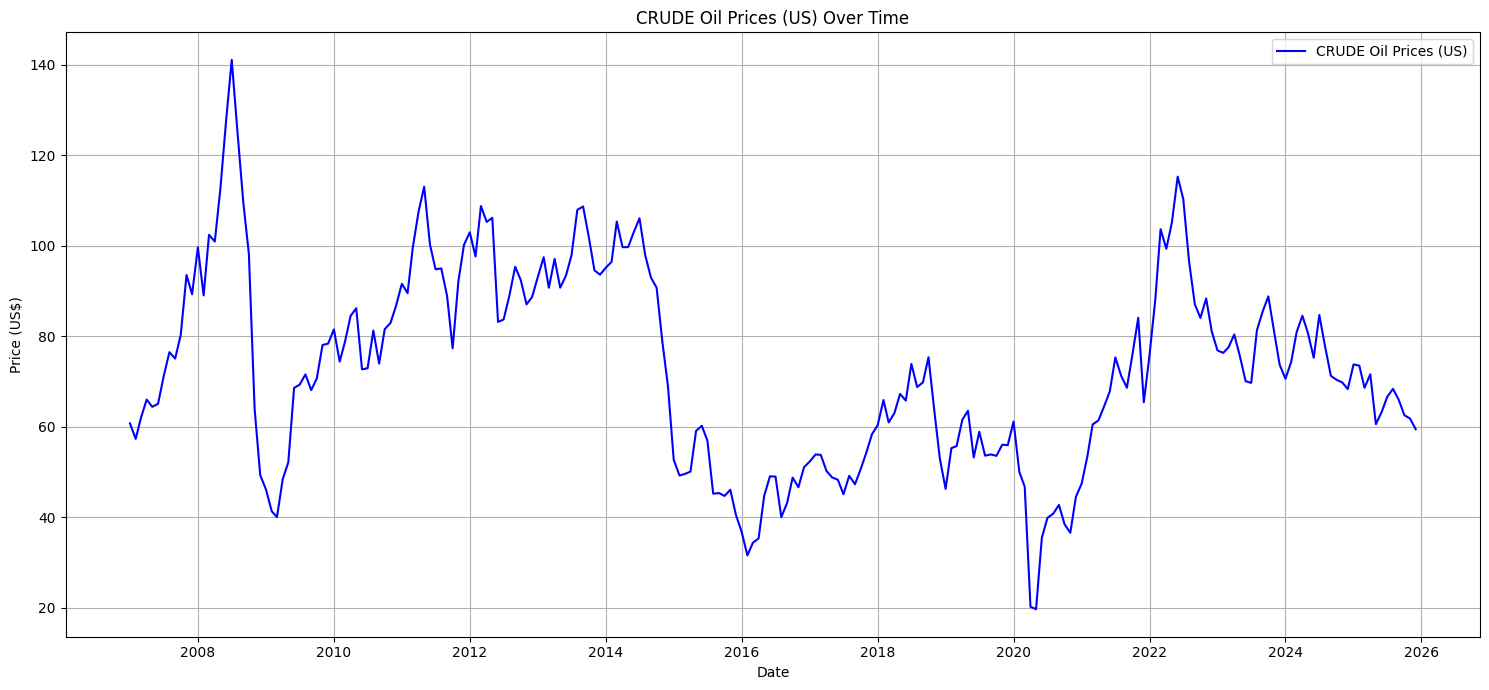

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(combined_data_monthly_filled.index, combined_data_monthly_filled['CRUDE Oil Prices (US)'], label='CRUDE Oil Prices (US)', color='blue')
plt.title('CRUDE Oil Prices (US) Over Time')
plt.xlabel('Date')
plt.ylabel('Price (US$)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

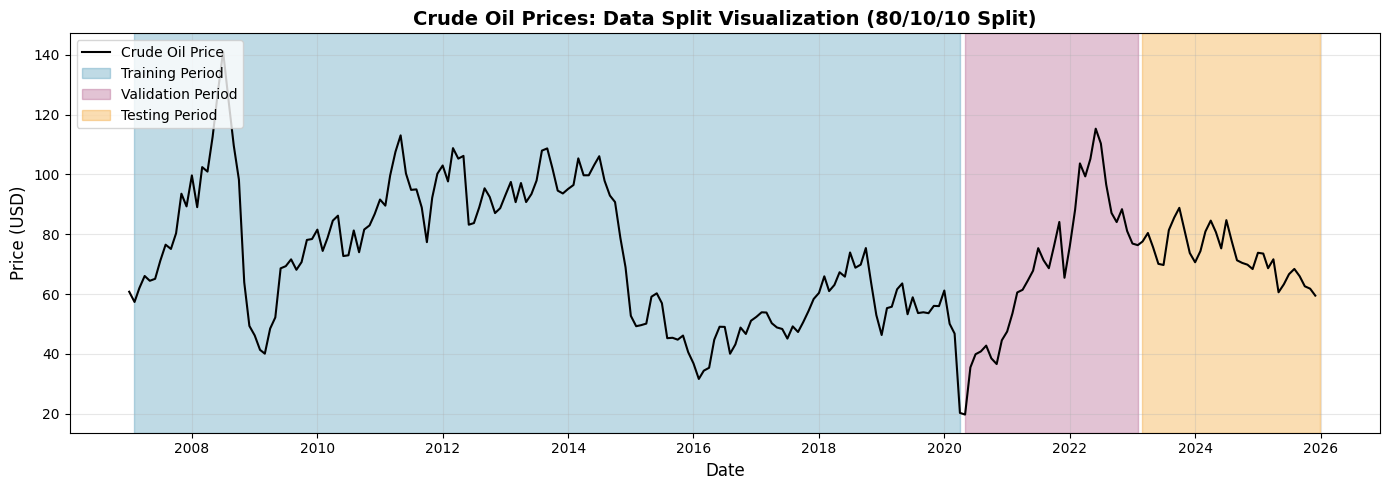

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
# Crude oil prices with regime highlighting
ax.plot(combined_data_monthly_filled.index, combined_data_monthly_filled['CRUDE Oil Prices (US)'],
         color='black', linewidth=1.5, label='Crude Oil Price')
ax.axvspan(train_data.index[0], train_data.index[-1], alpha=0.3, color='#2E86AB', label='Training Period')
ax.axvspan(val_data.index[0], val_data.index[-1], alpha=0.3, color='#A23B72', label='Validation Period')
ax.axvspan(test_data.index[0], test_data.index[-1], alpha=0.3, color='#F18F01', label='Testing Period')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_title('Crude Oil Prices: Data Split Visualization (80/10/10 Split)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Create datasets

Use a 0.8:0.1:0.1 split

In [ ]:
total_len = len(combined_data_monthly_filled)
train_end = int(total_len * 0.80)
val_end = int(total_len * 0.90)

train_data = combined_data_monthly_filled.iloc[:train_end]
val_data = combined_data_monthly_filled.iloc[train_end:val_end]
test_data = combined_data_monthly_filled.iloc[val_end:]

# STEP 4&5

## Data Discretisation

In [ ]:
hmm_models = {}
n_components = 3
covariance_type = 'full'
n_iter = 10000
random_state = 42

for column in train_data.columns:
    # Make series stationary
    X_series = train_data[column].diff().dropna().values.reshape(-1, 1)

    model = hmm.GaussianHMM(n_components=n_components, covariance_type=covariance_type,
                            n_iter=n_iter, random_state=random_state)

    try:
        model.fit(X_series)
        hmm_models[column] = model
        print(f"  HMM for {column} trained successfully.")
    except Exception as e:
        print(f"  Failed to train HMM for {column}: {e}")

  HMM for Median Consumer Price Index trained successfully.
  HMM for Industrial Production: Total Index trained successfully.
  HMM for Gross Domestic Product trained successfully.
  HMM for USD Dollar Index trained successfully.
  HMM for US Gasoline Consumption trained successfully.
  HMM for Global Economic Activity Index trained successfully.
  HMM for CRUDE Oil Prices (US) trained successfully.
  HMM for OVX trained successfully.
  HMM for Nasdaq trained successfully.
  HMM for 10Y_Treasury trained successfully.
  HMM for XLE trained successfully.
  HMM for S&P_500 trained successfully.


Target = CRUDE Oil Prices,
Rest features/Variables

In [ ]:
hmm_states_mapping = {}

for column_name, model in hmm_models.items():
    state_means = model.means_.flatten()
    sorted_state_indices = np.argsort(state_means)

    bear_state = sorted_state_indices[0]
    bull_state = sorted_state_indices[-1]
    stagnant_state = sorted_state_indices[1] if len(sorted_state_indices) > 2 else None

    hmm_states_mapping[column_name] = {
        'bear_state': bear_state,
        'bull_state': bull_state,
        'stagnant_state': stagnant_state,
        'state_means': state_means.tolist()
    }

# Convert hmm_states_mapping to a DataFrame for better display
data_for_df = []
for column, states in hmm_states_mapping.items():
    bear_mean = states['state_means'][states['bear_state']]
    stagnant_mean = states['state_means'][states['stagnant_state']] if states['stagnant_state'] is not None else np.nan
    bull_mean = states['state_means'][states['bull_state']]

    data_for_df.append({
        'Variable': column,
        'Bear State Index': states['bear_state'],
        'Bear State Mean': f'{bear_mean:.2f}',
        'Stagnant State Index': states['stagnant_state'],
        'Stagnant State Mean': f'{stagnant_mean:.2f}' if not np.isnan(stagnant_mean) else 'N/A',
        'Bull State Index': states['bull_state'],
        'Bull State Mean': f'{bull_mean:.2f}'
    })

hmm_states_df = pd.DataFrame(data_for_df)
display(hmm_states_df)

,Variable,Bear State Index,Bear State Mean,Stagnant State Index,Stagnant State Mean,Bull State Index,Bull State Mean
0,Median Consumer Price Index,0,-0.24,1,0.03,2,1.44
1,Industrial Production: Total Index,1,-12.85,0,-0.35,2,0.12
2,Gross Domestic Product,0,-1792.95,1,0.00,2,223.98
3,USD Dollar Index,1,-0.43,2,0.24,0,0.56
4,US Gasoline Consumption,2,-34.45,1,1.67,0,3.50
5,Global Economic Activity Index,0,-18.52,1,-7.47,2,4.09
6,CRUDE Oil Prices (US),2,-15.05,1,0.67,0,2.13
7,OVX,2,-0.58,0,6.52,1,110.65
8,Nasdaq,1,-86.33,2,38.47,0,421.94
9,10Y_Treasury,2,-0.88,0,-0.02,1,0.01


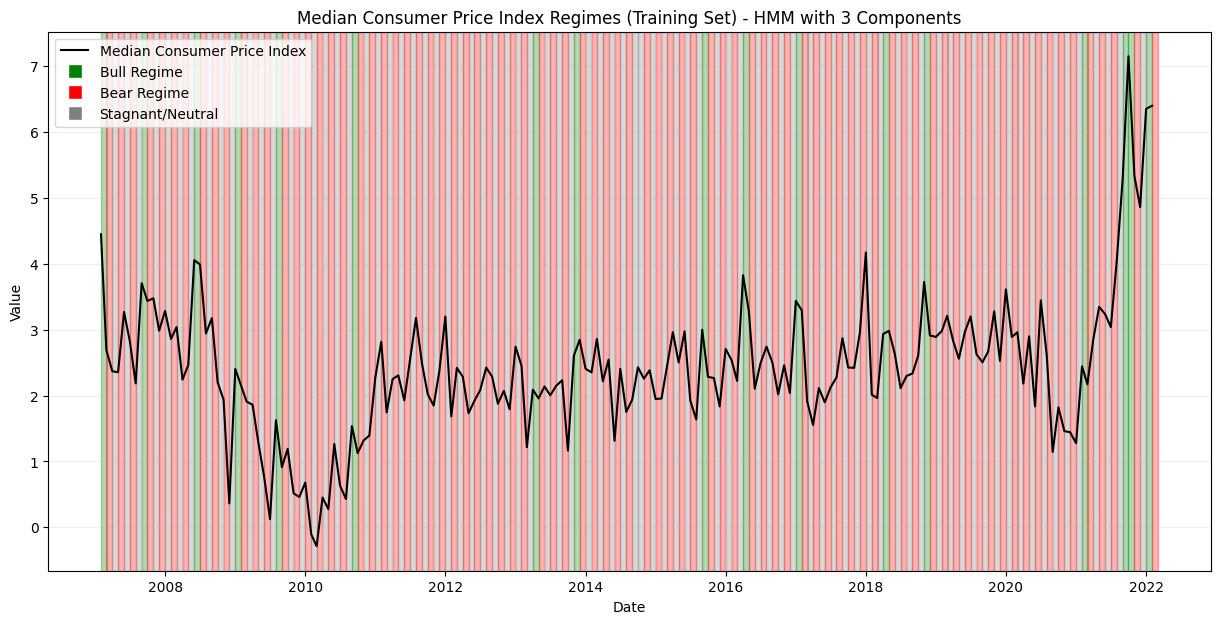

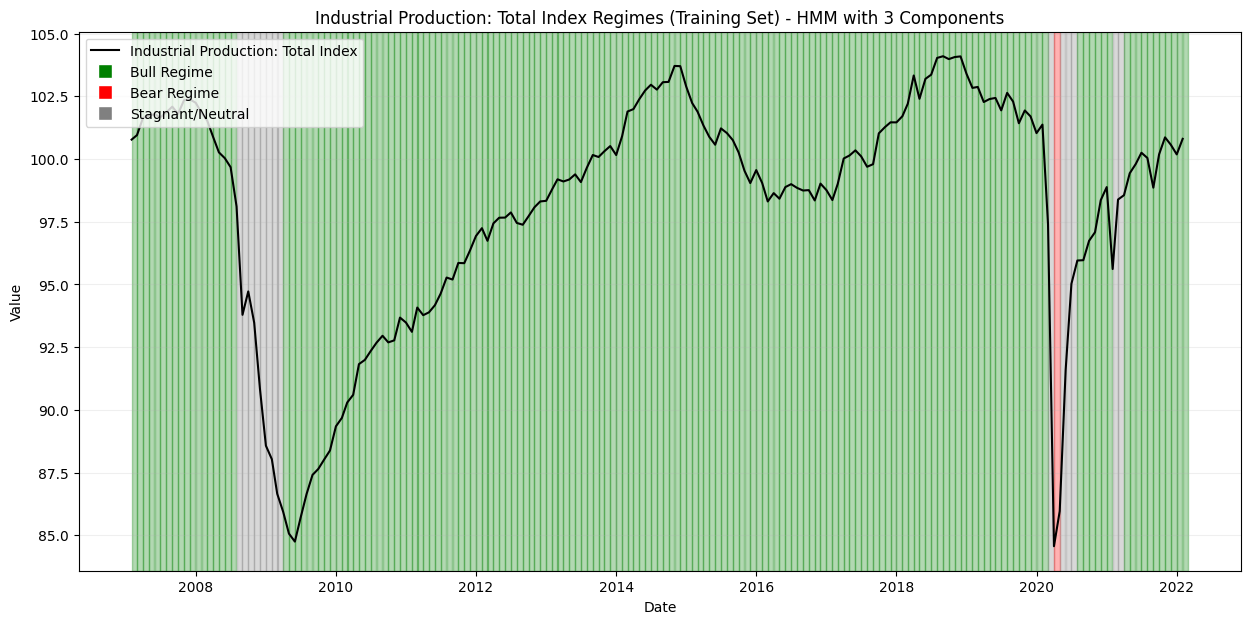

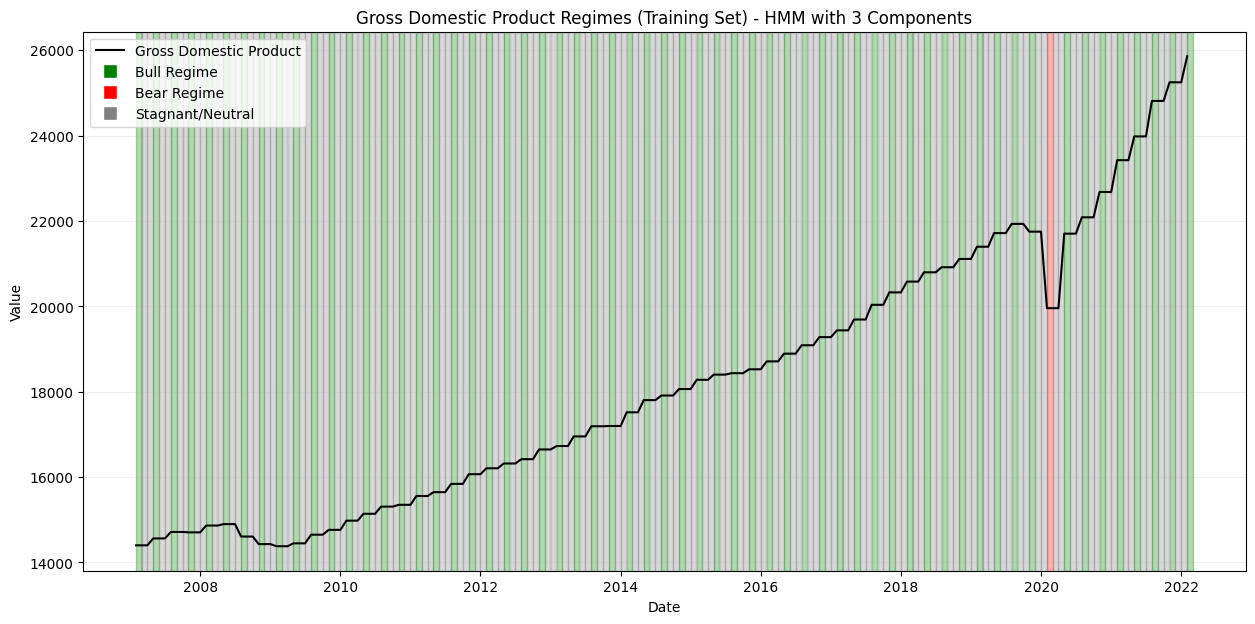

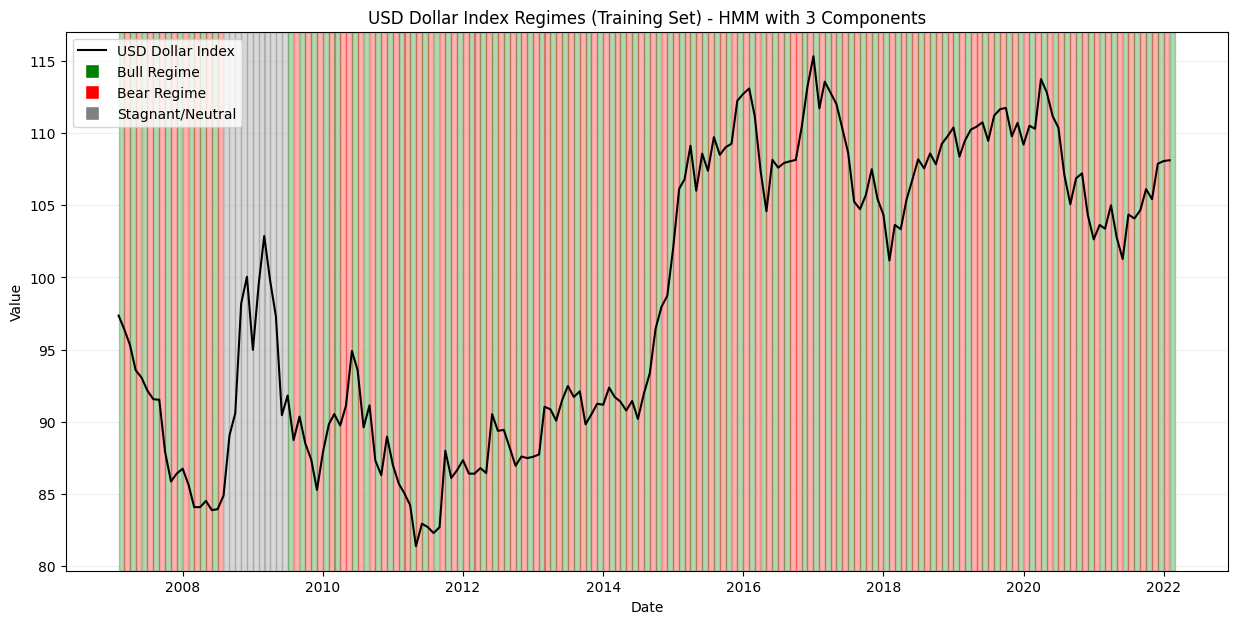

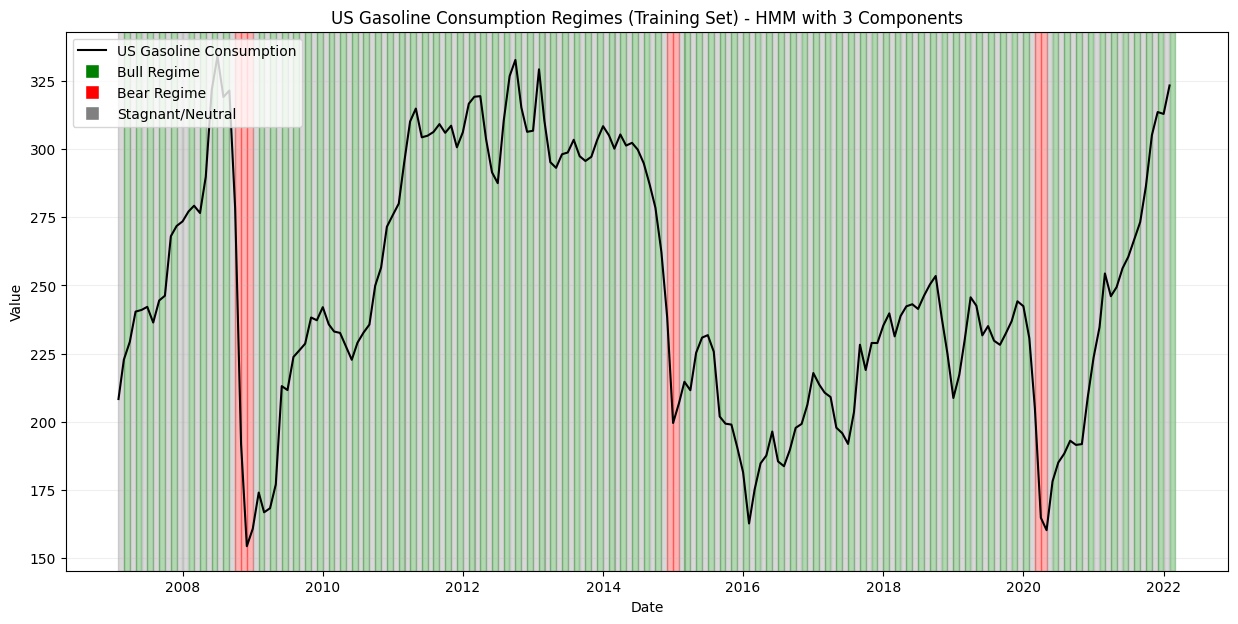

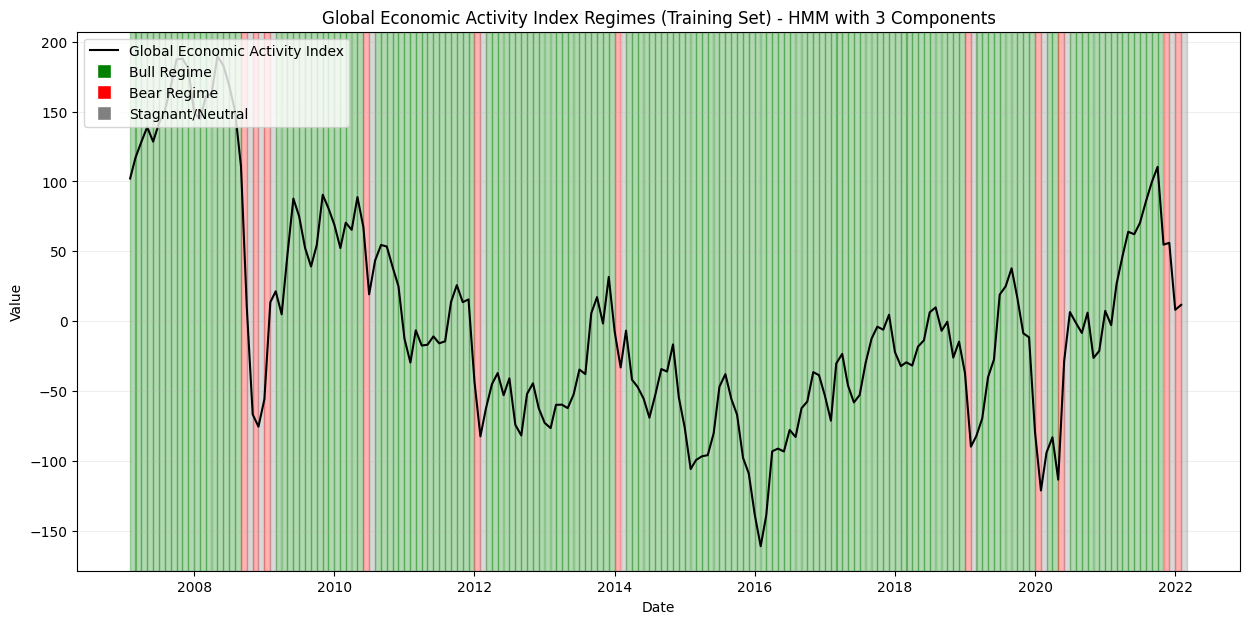

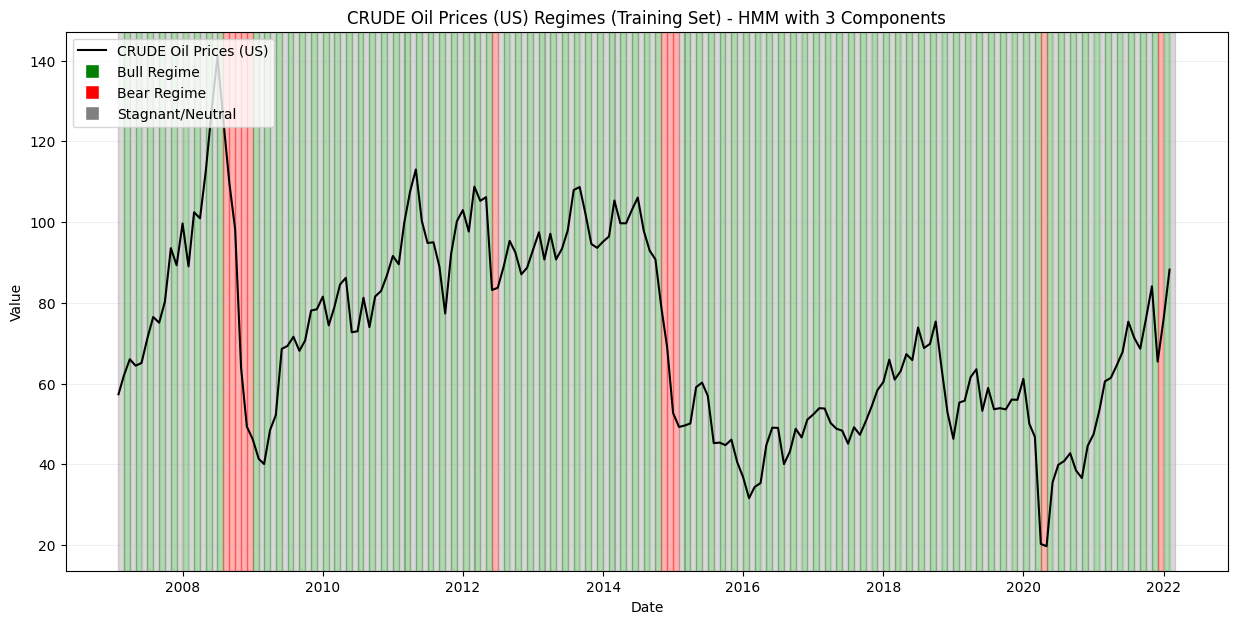

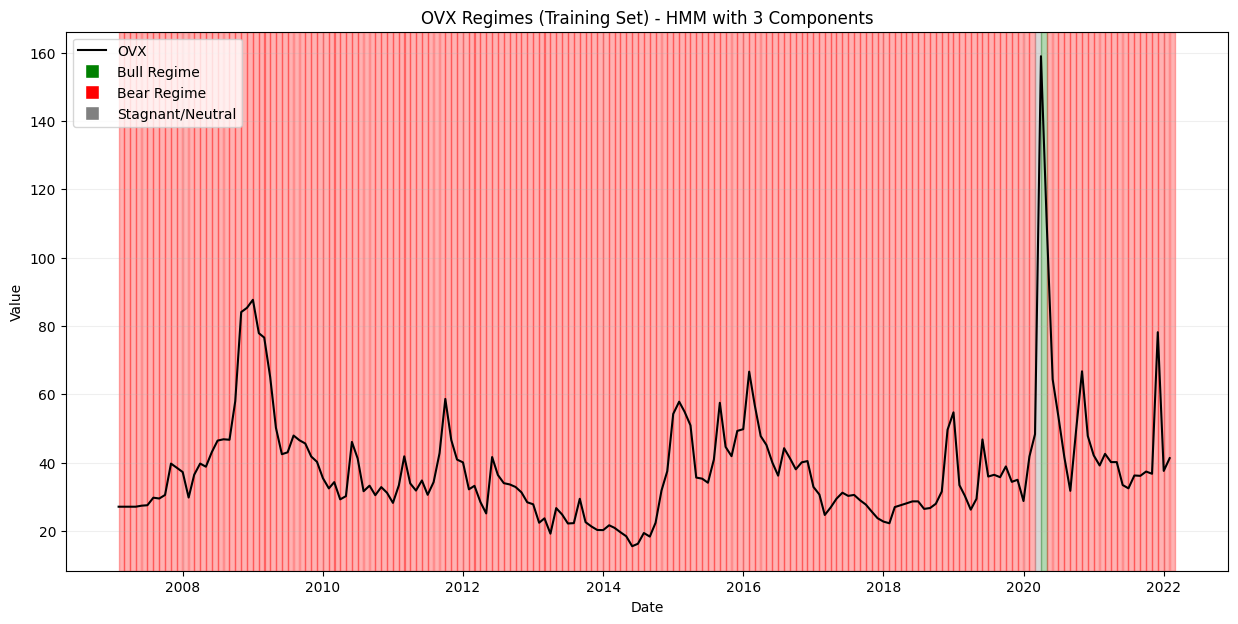

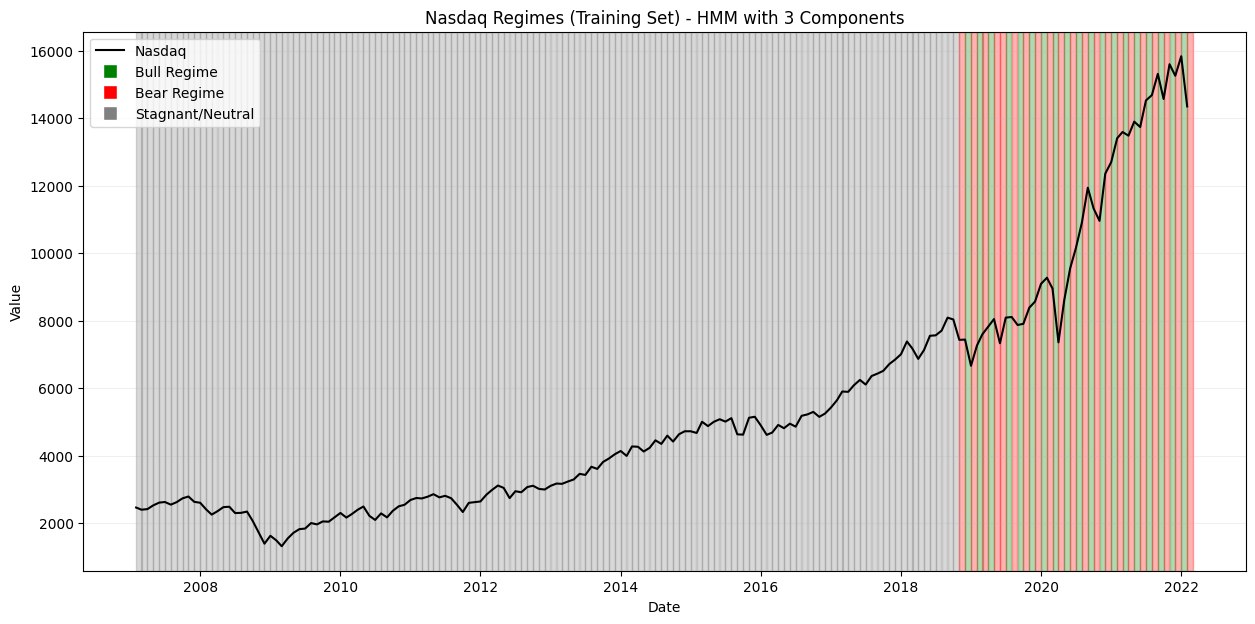

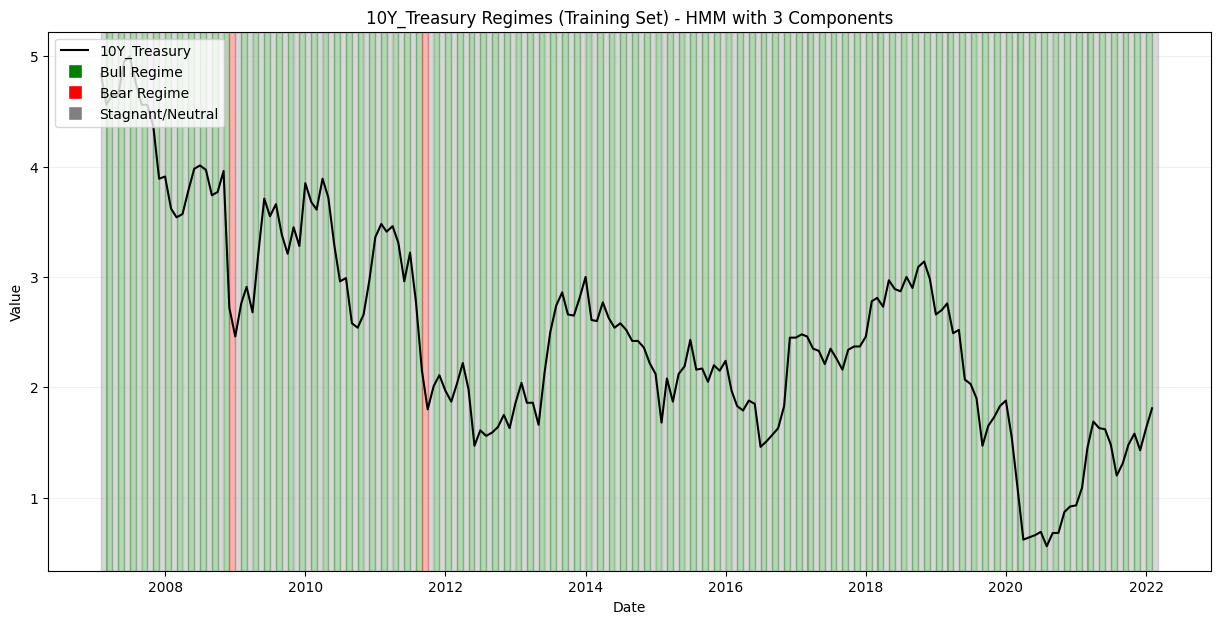

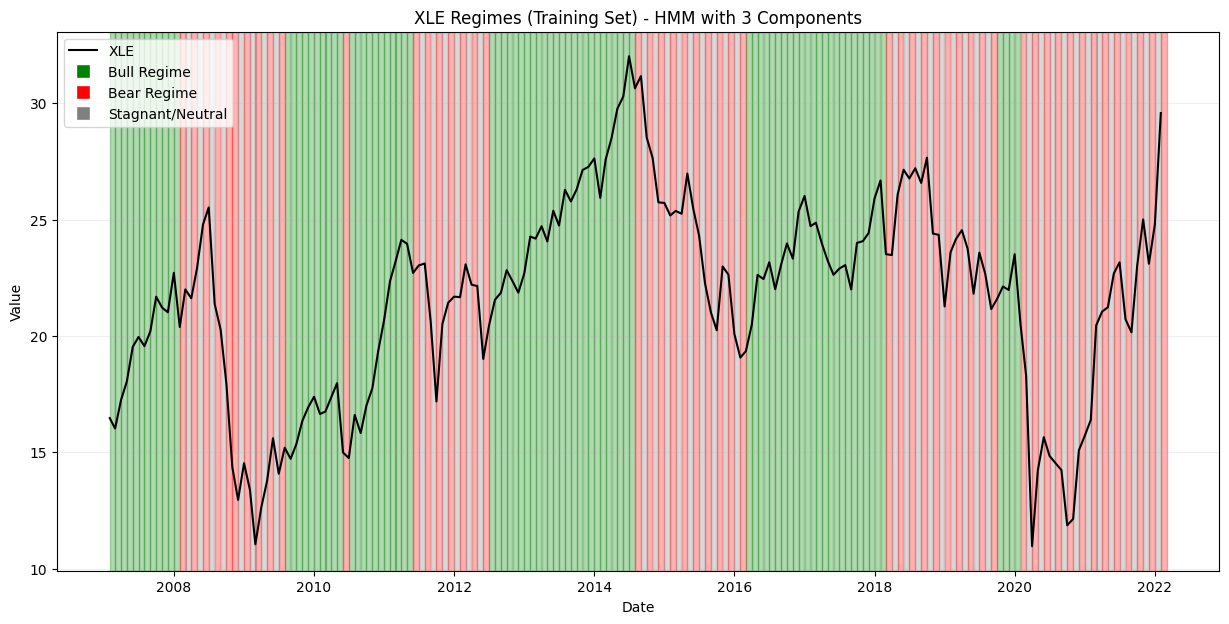

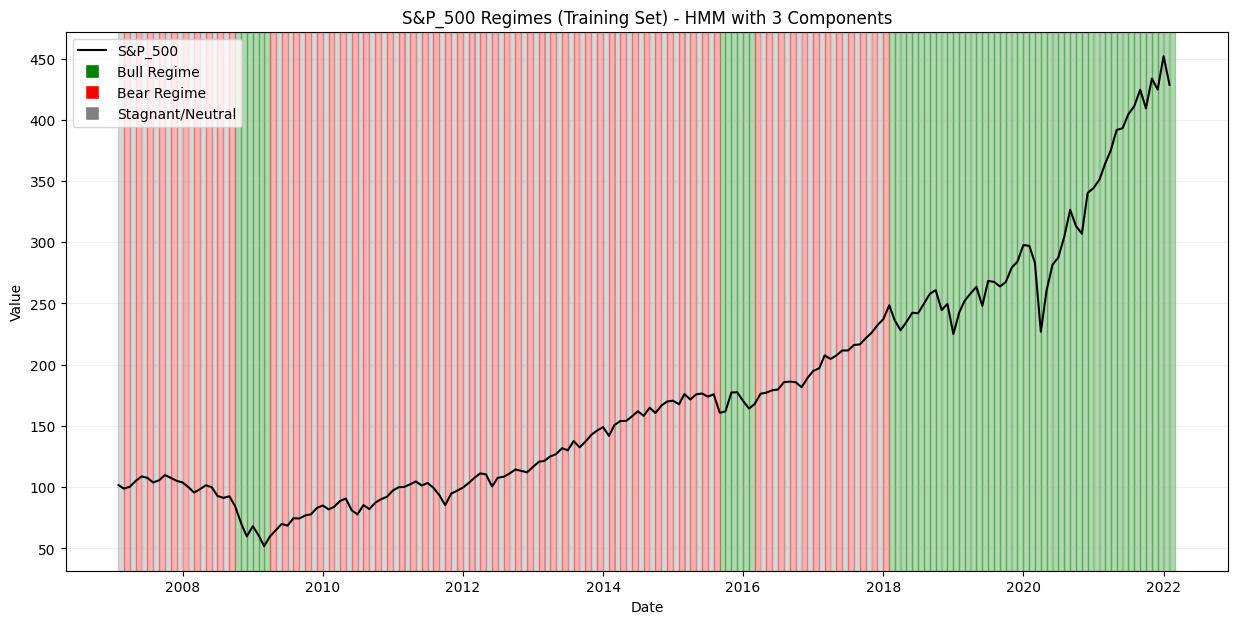

In [ ]:
all_hidden_states = {}

for column_name, model in hmm_models.items():
    # Prepare the differenced series for prediction
    X_series_diff = train_data[column_name].diff().dropna().values.reshape(-1, 1)

    original_series = train_data[column_name].iloc[1:]
    dates_for_plot = original_series.index

    # Predict hidden states
    if len(X_series_diff) > 0:
        hidden_states = model.predict(X_series_diff)
        all_hidden_states[column_name] = hidden_states
    else:
        print(f"Skipping {column_name} due to insufficient data after differencing.")
        continue

    states_map = hmm_states_mapping[column_name]
    bear_state = states_map['bear_state']
    bull_state = states_map['bull_state']
    stagnant_state = states_map['stagnant_state']

    plt.figure(figsize=(15, 7))
    plt.plot(dates_for_plot, original_series, color='black', lw=1.5, label=f'{column_name} Price/Index')

    # regimes
    for i in range(len(hidden_states)):
        state = hidden_states[i]
        color = 'green' if state == bull_state else ('red' if state == bear_state else 'gray')
        if i < len(dates_for_plot):
            plt.axvspan(dates_for_plot[i], dates_for_plot[i] + pd.Timedelta(days=30), color=color, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, label=f'{column_name}'),
        Line2D([0], [0], marker='s', color='w', label='Bull Regime', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Bear Regime', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Stagnant/Neutral', markerfacecolor='gray', markersize=10)
    ]

    plt.title(f'{column_name} Regimes (Training Set) - HMM with 3 Components')
    plt.ylabel('Value')
    plt.xlabel('Date')
    plt.legend(handles=legend_elements, loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

Discrete time data to be used in the pgm

In [ ]:
hidden_states_df = pd.DataFrame()

for column_name, hidden_states_array in all_hidden_states.items():
    dates_for_states = train_data[column_name].iloc[1:].index
    hidden_states_df[column_name] = pd.Series(hidden_states_array, index=dates_for_states)

display(hidden_states_df.head())


,Median Consumer Price Index,Industrial Production: Total Index,Gross Domestic Product,USD Dollar Index,US Gasoline Consumption,Global Economic Activity Index,CRUDE Oil Prices (US),OVX,Nasdaq,10Y_Treasury,XLE,S&P_500
2007-02-01,2,2,2,0,1,2,1,2,2,0,2,0
2007-03-01,0,2,1,1,0,2,0,2,2,1,2,1
2007-04-01,1,2,1,0,1,2,1,2,2,0,2,0
2007-05-01,0,2,2,1,0,2,0,2,2,1,2,1
2007-06-01,1,2,1,0,1,2,1,2,2,0,2,0


## Learning Bayesian Network using Hill Climbing

The PGM model is build using regimes

Learn structure using different scoring functions

In [ ]:
scoring_methods = {
    'BIC': BIC(hidden_states_df),
    'K2': K2(hidden_states_df),
    'BDeu': BDeu(hidden_states_df),
    'BDs': BDs(hidden_states_df)
}

hc = HillClimbSearch(hidden_states_df)

learned_edges_dict = {}
learned_pgm_models_dict = {}

for name, scoring_method in scoring_methods.items():
    print(f"\nEstimating model using {name} scoring method...")
    model = hc.estimate(scoring_method=scoring_method)
    learned_pgm_models_dict[name] = model
    learned_edges_dict[name] = list(model.edges())
    print(f"{name} Learned Edges:")
    print(model.edges())


Estimating model using BIC scoring method...


  0%|          | 0/1000000 [00:00<?, ?it/s]

BIC Learned Edges:
[('USD Dollar Index', '10Y_Treasury'), ('USD Dollar Index', 'Industrial Production: Total Index'), ('US Gasoline Consumption', 'CRUDE Oil Prices (US)'), ('US Gasoline Consumption', 'XLE'), ('XLE', 'USD Dollar Index'), ('S&P_500', 'Nasdaq'), ('S&P_500', 'US Gasoline Consumption'), ('S&P_500', 'XLE')]

Estimating model using K2 scoring method...


  0%|          | 0/1000000 [00:00<?, ?it/s]

K2 Learned Edges:
[('Median Consumer Price Index', 'US Gasoline Consumption'), ('Median Consumer Price Index', 'USD Dollar Index'), ('Median Consumer Price Index', 'XLE'), ('Median Consumer Price Index', 'CRUDE Oil Prices (US)'), ('Median Consumer Price Index', 'Nasdaq'), ('Median Consumer Price Index', 'Global Economic Activity Index'), ('Median Consumer Price Index', 'S&P_500'), ('Industrial Production: Total Index', 'USD Dollar Index'), ('Industrial Production: Total Index', 'US Gasoline Consumption'), ('Industrial Production: Total Index', 'XLE'), ('Industrial Production: Total Index', 'CRUDE Oil Prices (US)'), ('Industrial Production: Total Index', 'Global Economic Activity Index'), ('Industrial Production: Total Index', 'Nasdaq'), ('Industrial Production: Total Index', 'S&P_500'), ('Gross Domestic Product', 'US Gasoline Consumption'), ('Gross Domestic Product', 'USD Dollar Index'), ('Gross Domestic Product', 'XLE'), ('Gross Domestic Product', 'CRUDE Oil Prices (US)'), ('Gross Dom

  0%|          | 0/1000000 [00:00<?, ?it/s]

BDeu Learned Edges:
[('Industrial Production: Total Index', 'OVX'), ('Industrial Production: Total Index', 'Global Economic Activity Index'), ('USD Dollar Index', '10Y_Treasury'), ('USD Dollar Index', 'Industrial Production: Total Index'), ('USD Dollar Index', 'CRUDE Oil Prices (US)'), ('US Gasoline Consumption', '10Y_Treasury'), ('US Gasoline Consumption', 'CRUDE Oil Prices (US)'), ('OVX', 'Gross Domestic Product'), ('Nasdaq', 'S&P_500'), ('Nasdaq', 'USD Dollar Index'), ('Nasdaq', 'Industrial Production: Total Index'), ('Nasdaq', 'XLE'), ('Nasdaq', 'US Gasoline Consumption'), ('10Y_Treasury', 'Global Economic Activity Index'), ('10Y_Treasury', 'CRUDE Oil Prices (US)'), ('XLE', 'USD Dollar Index'), ('XLE', 'US Gasoline Consumption'), ('XLE', 'CRUDE Oil Prices (US)'), ('S&P_500', 'US Gasoline Consumption'), ('S&P_500', 'XLE'), ('S&P_500', 'CRUDE Oil Prices (US)'), ('S&P_500', 'USD Dollar Index')]

Estimating model using BDs scoring method...


  0%|          | 0/1000000 [00:00<?, ?it/s]

BDs Learned Edges:
[('Industrial Production: Total Index', 'OVX'), ('Industrial Production: Total Index', 'Global Economic Activity Index'), ('USD Dollar Index', '10Y_Treasury'), ('USD Dollar Index', 'Industrial Production: Total Index'), ('USD Dollar Index', 'CRUDE Oil Prices (US)'), ('US Gasoline Consumption', '10Y_Treasury'), ('US Gasoline Consumption', 'CRUDE Oil Prices (US)'), ('US Gasoline Consumption', 'Industrial Production: Total Index'), ('OVX', 'Gross Domestic Product'), ('Nasdaq', 'S&P_500'), ('Nasdaq', 'USD Dollar Index'), ('XLE', 'USD Dollar Index'), ('XLE', 'US Gasoline Consumption'), ('S&P_500', 'US Gasoline Consumption'), ('S&P_500', 'XLE')]


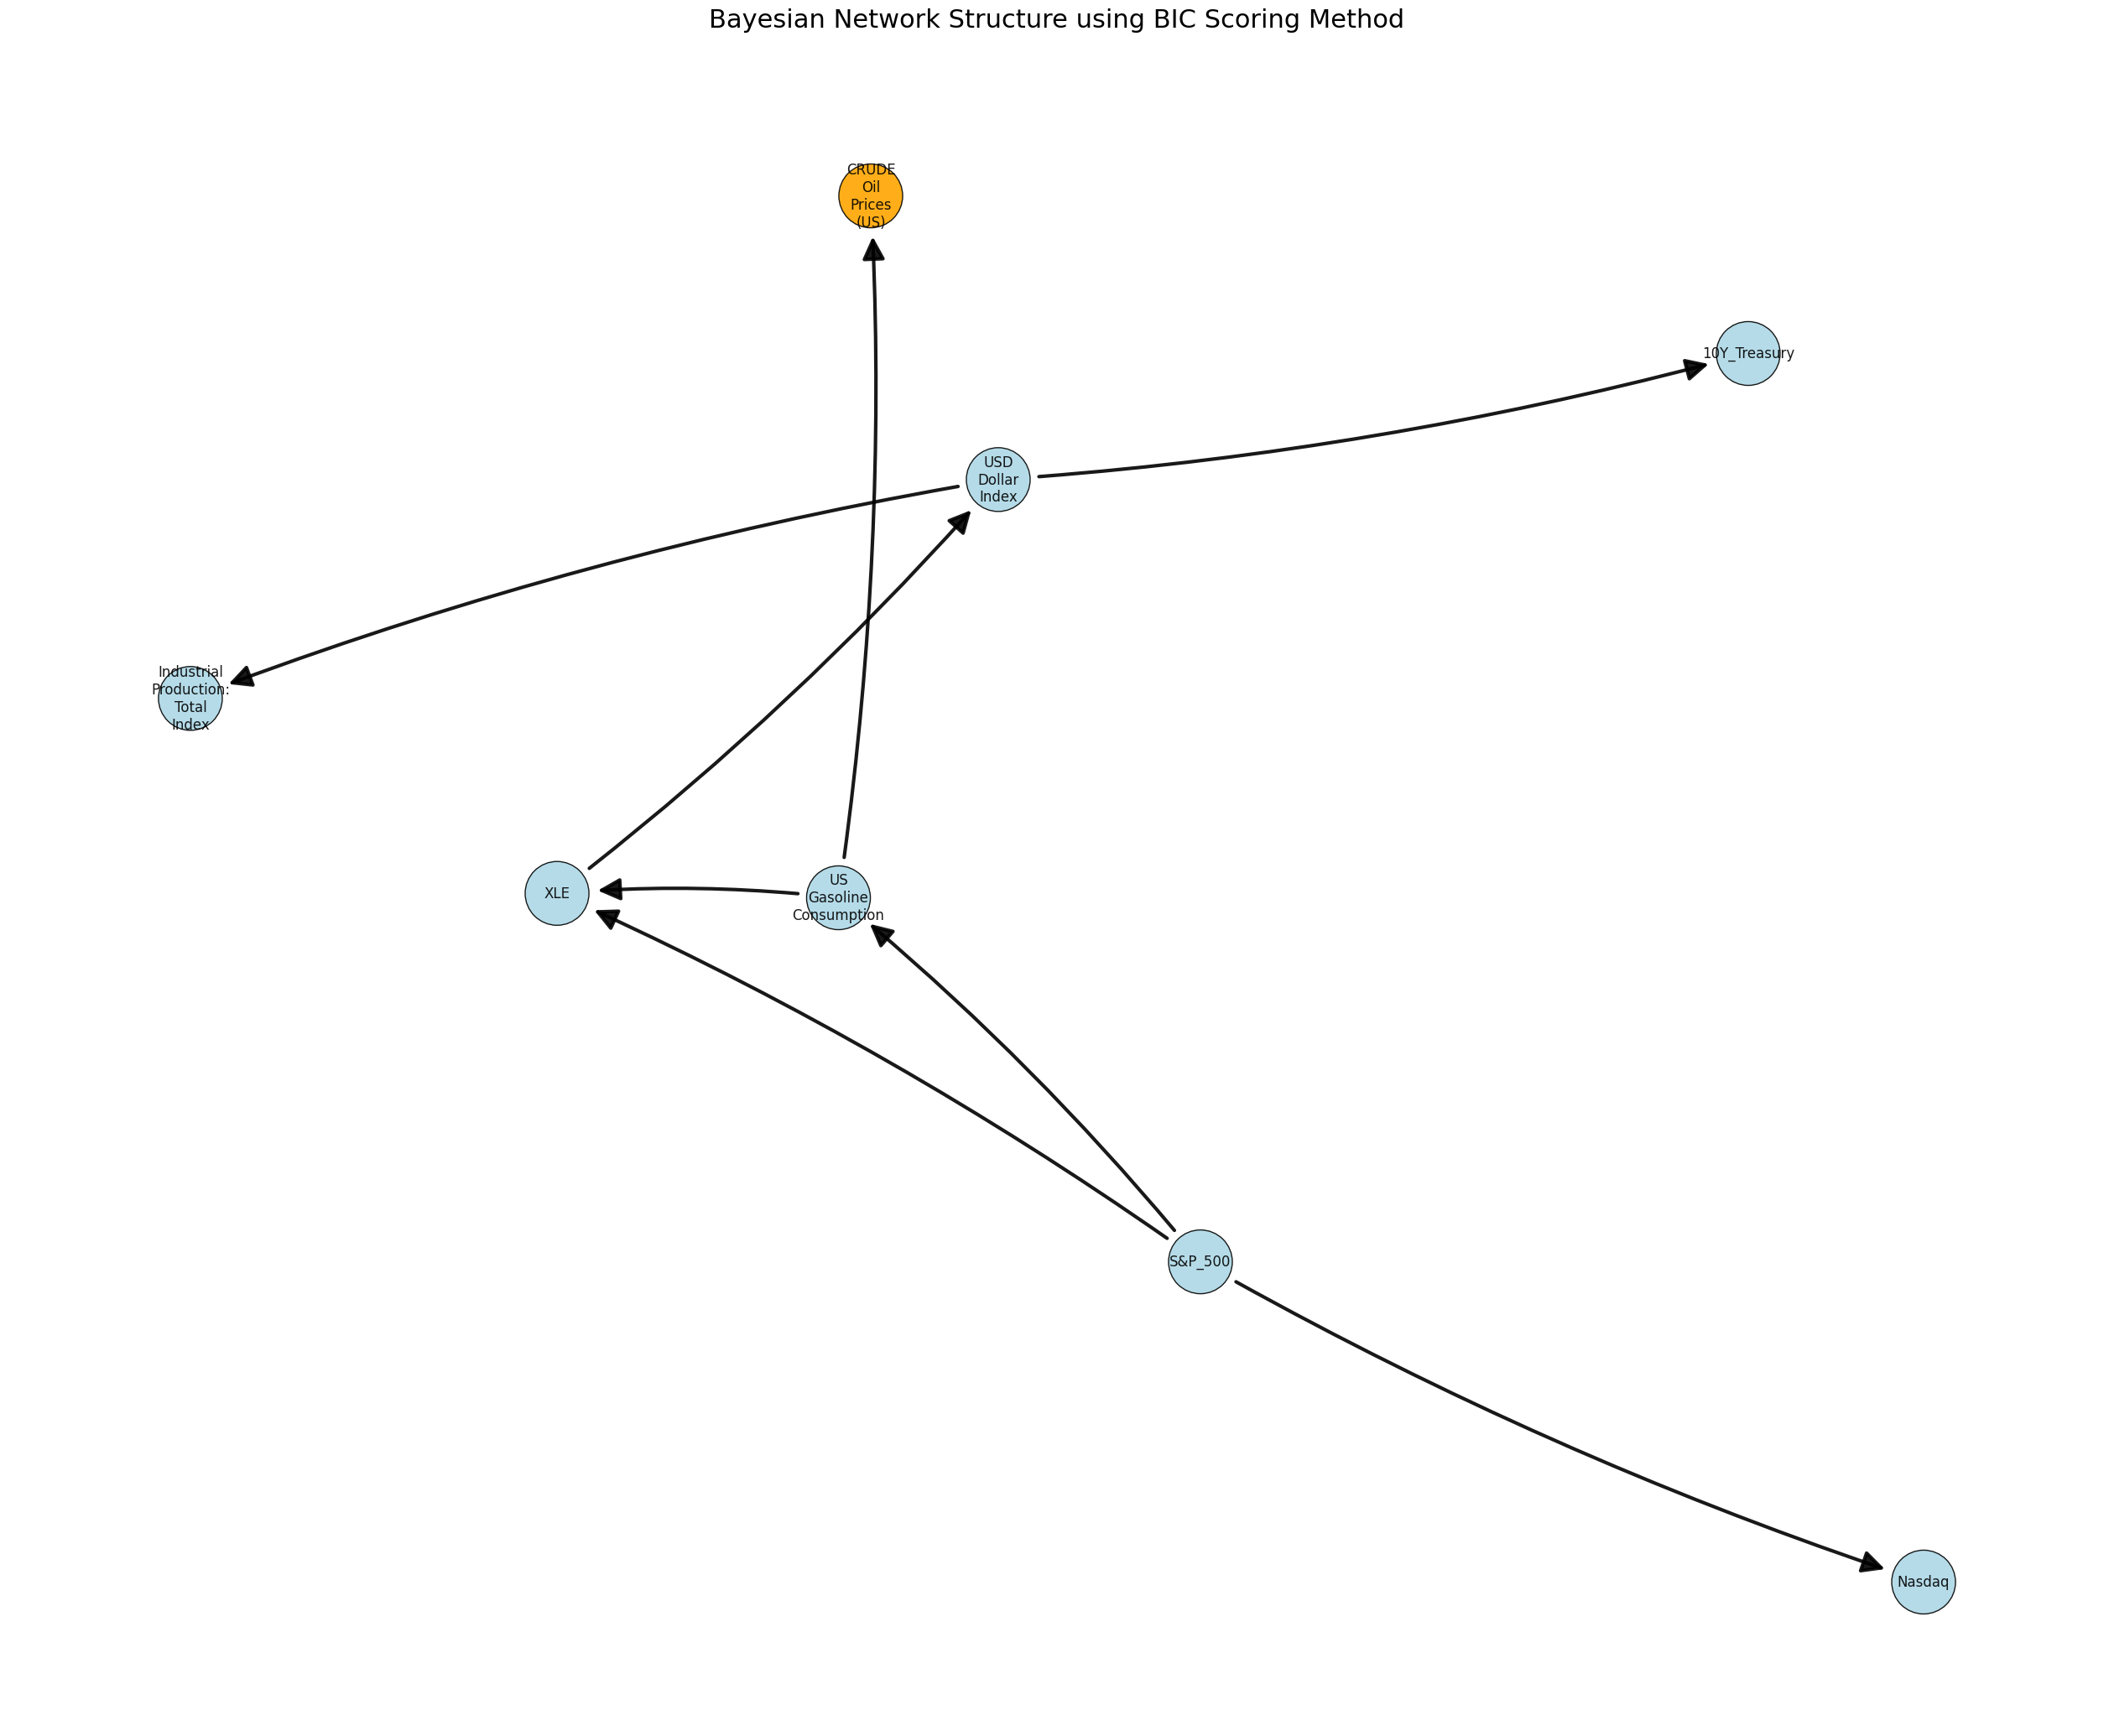

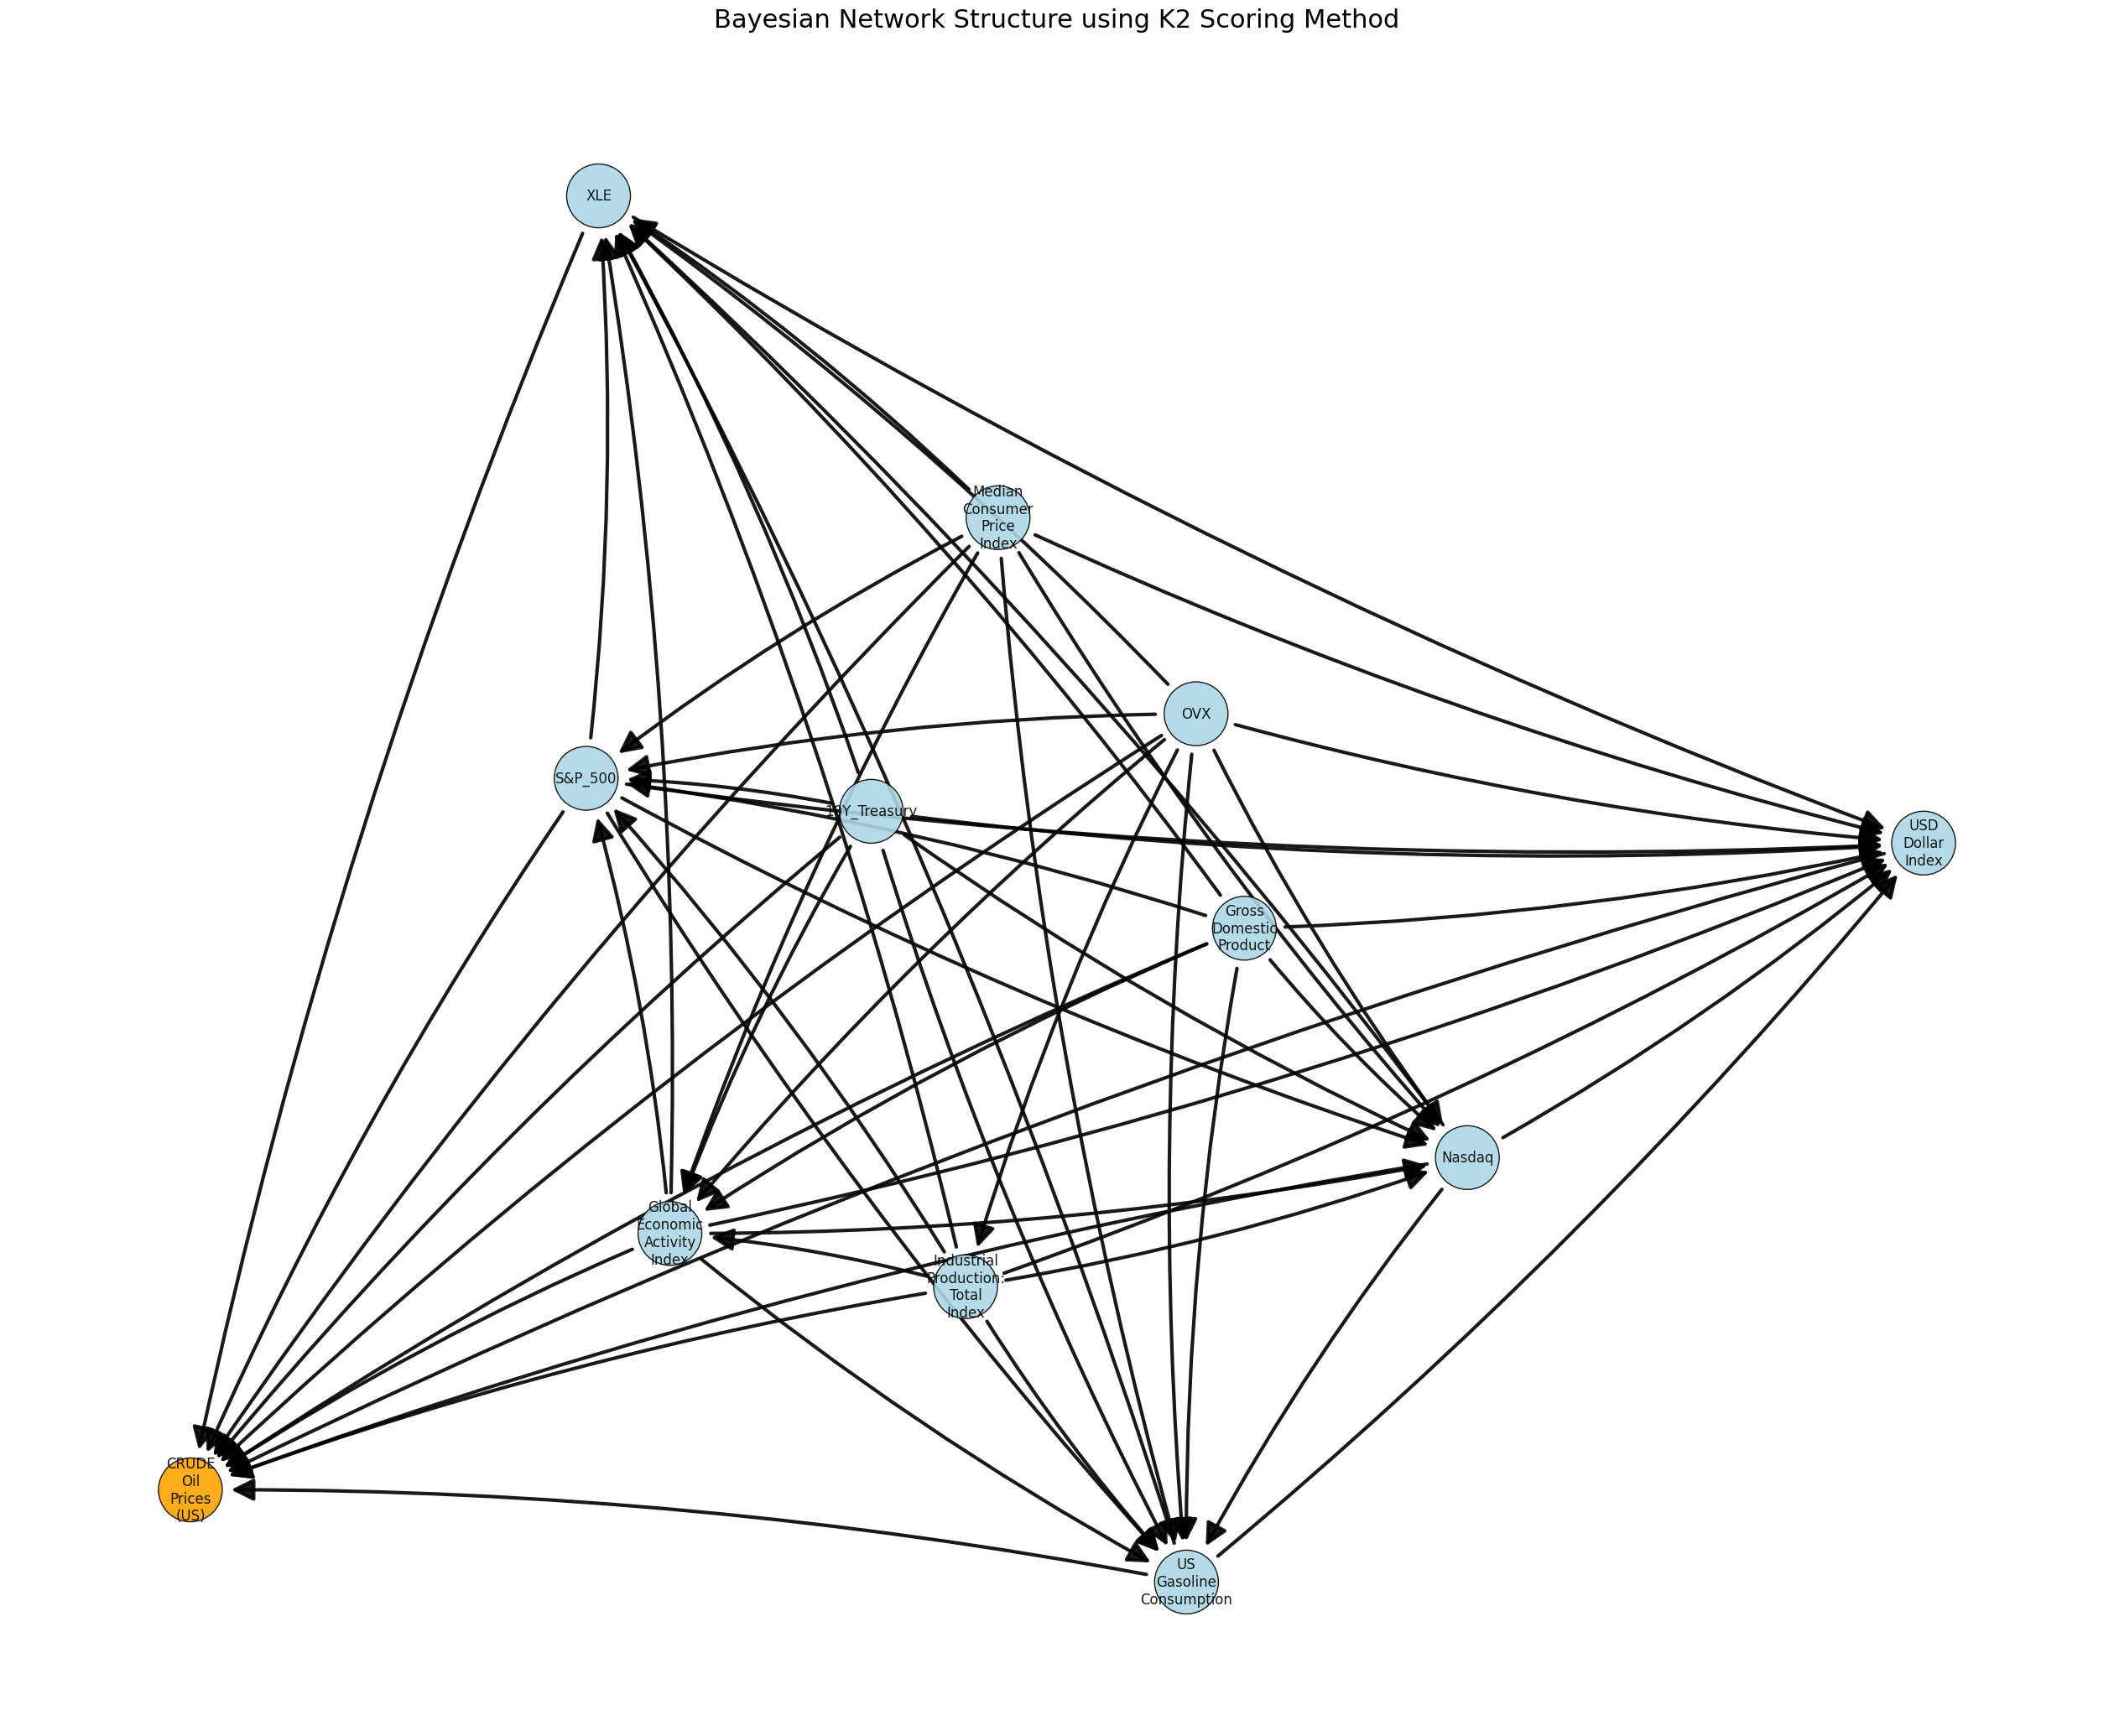

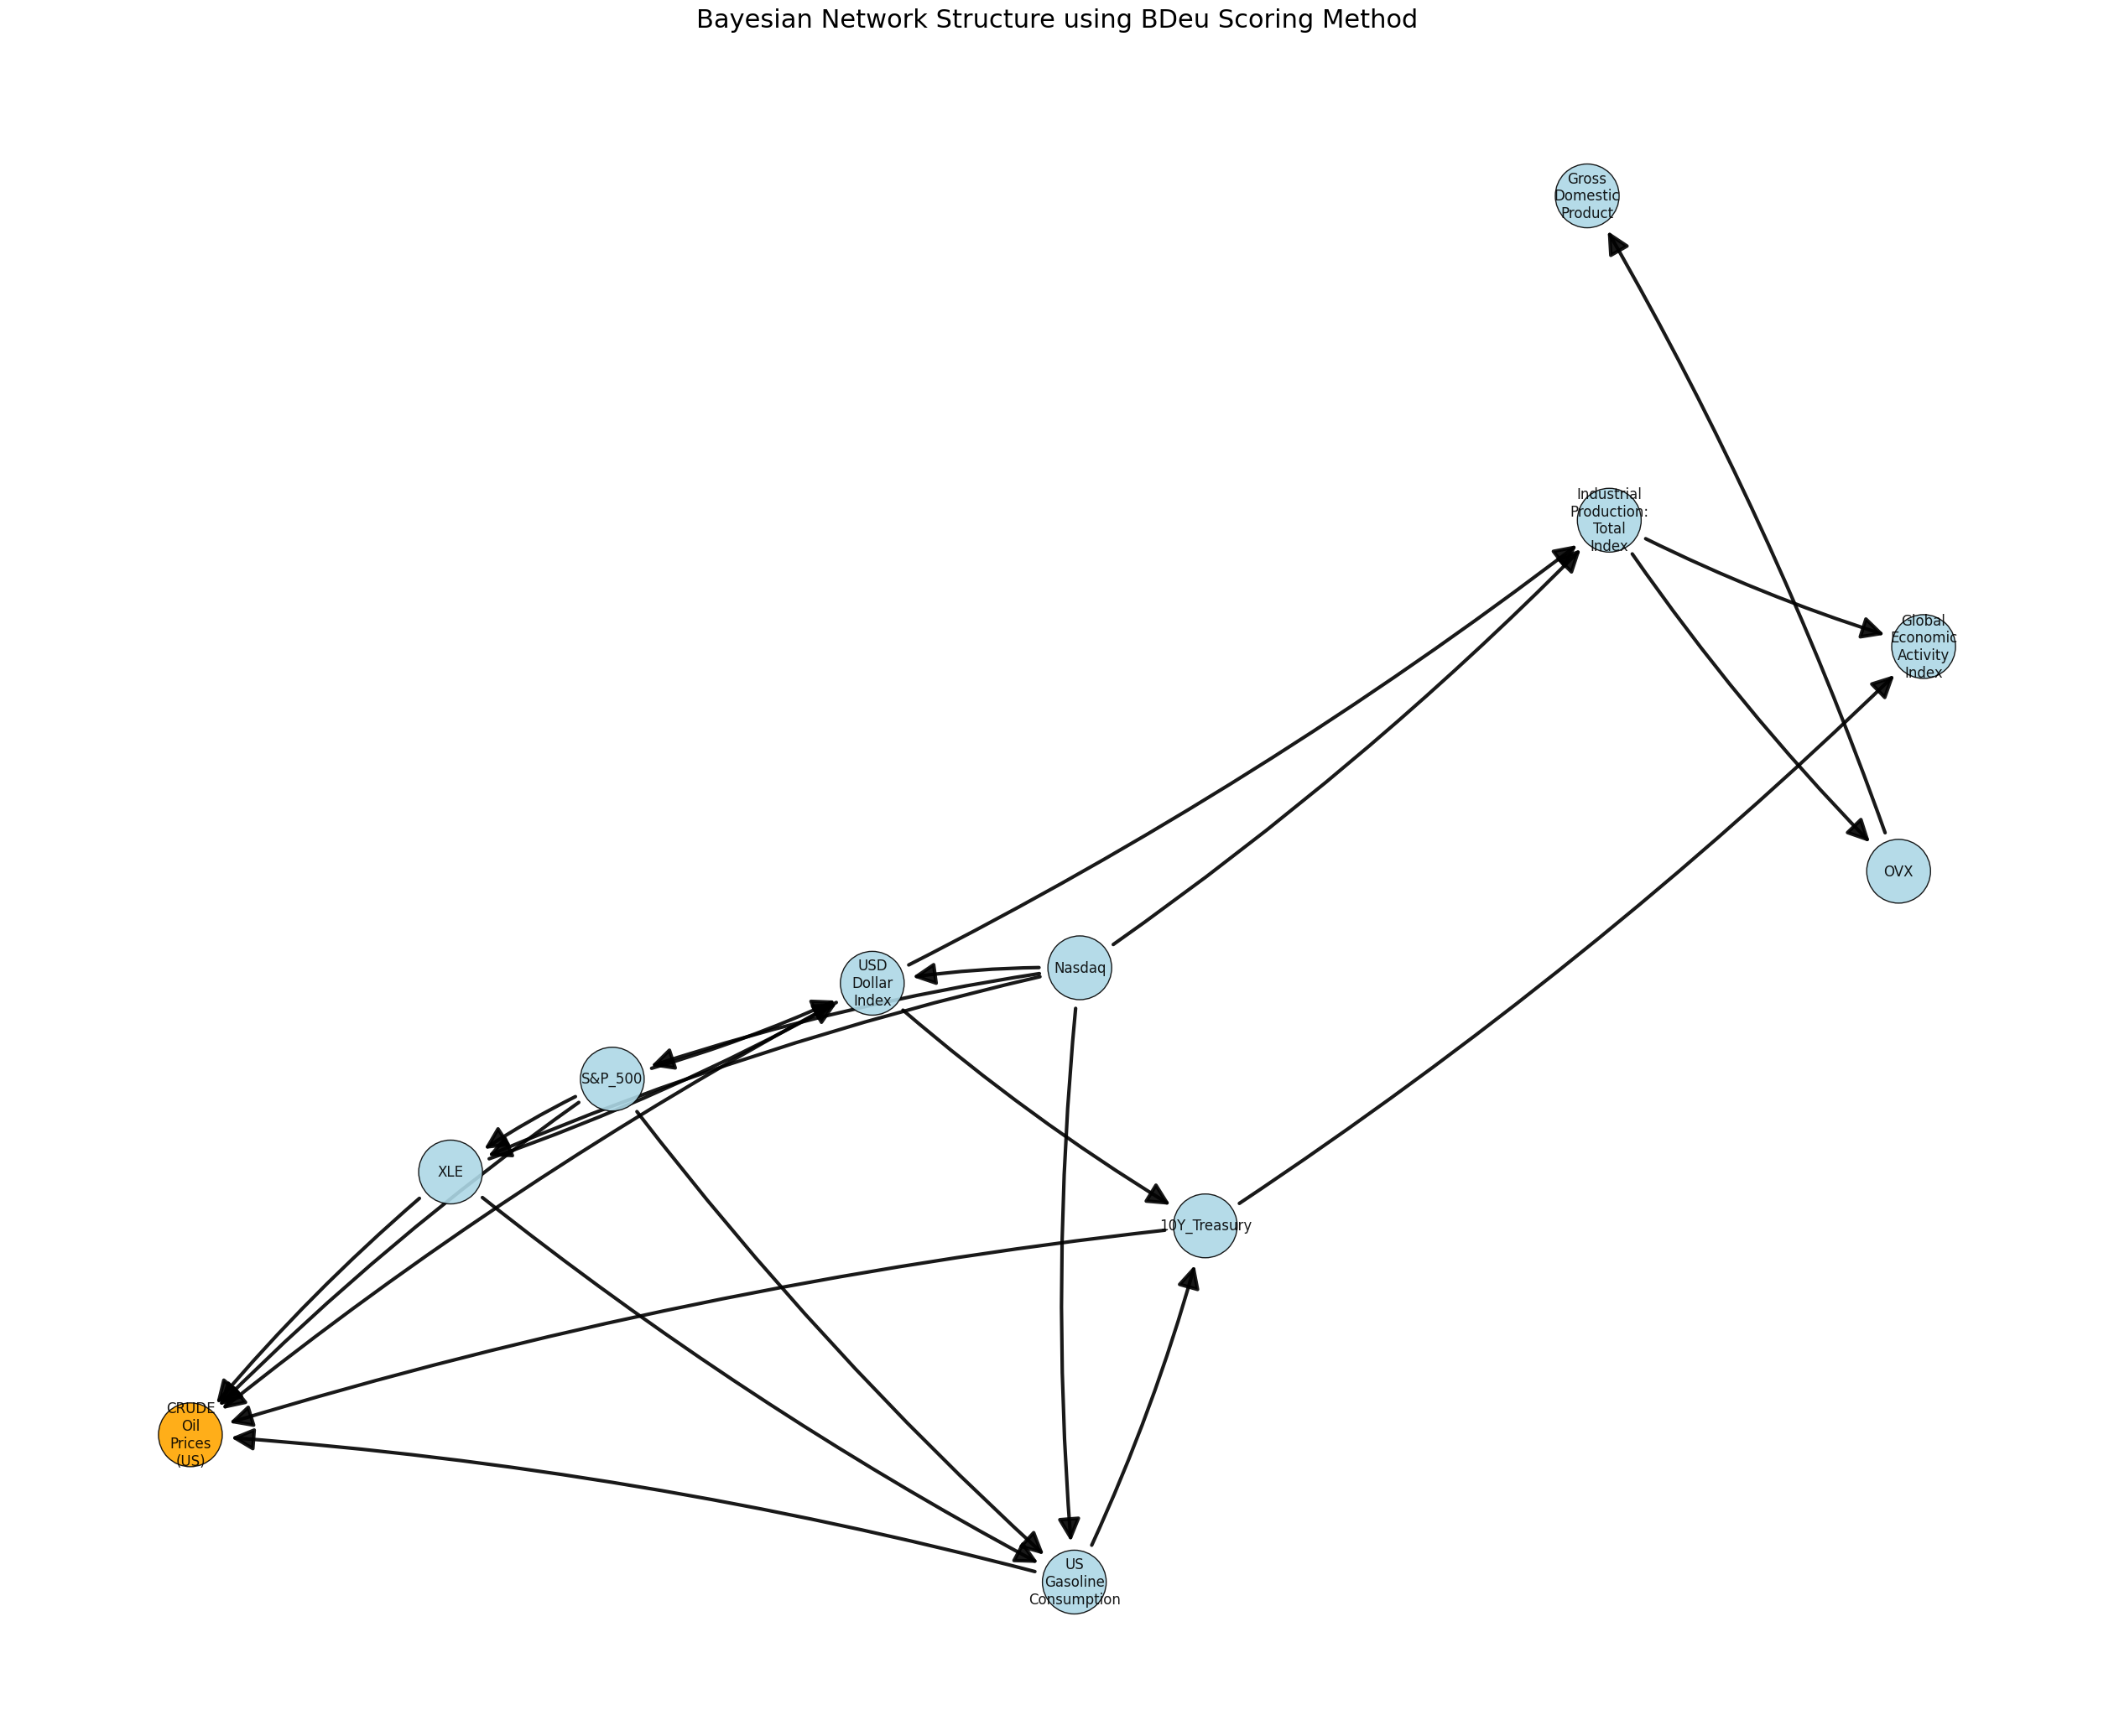

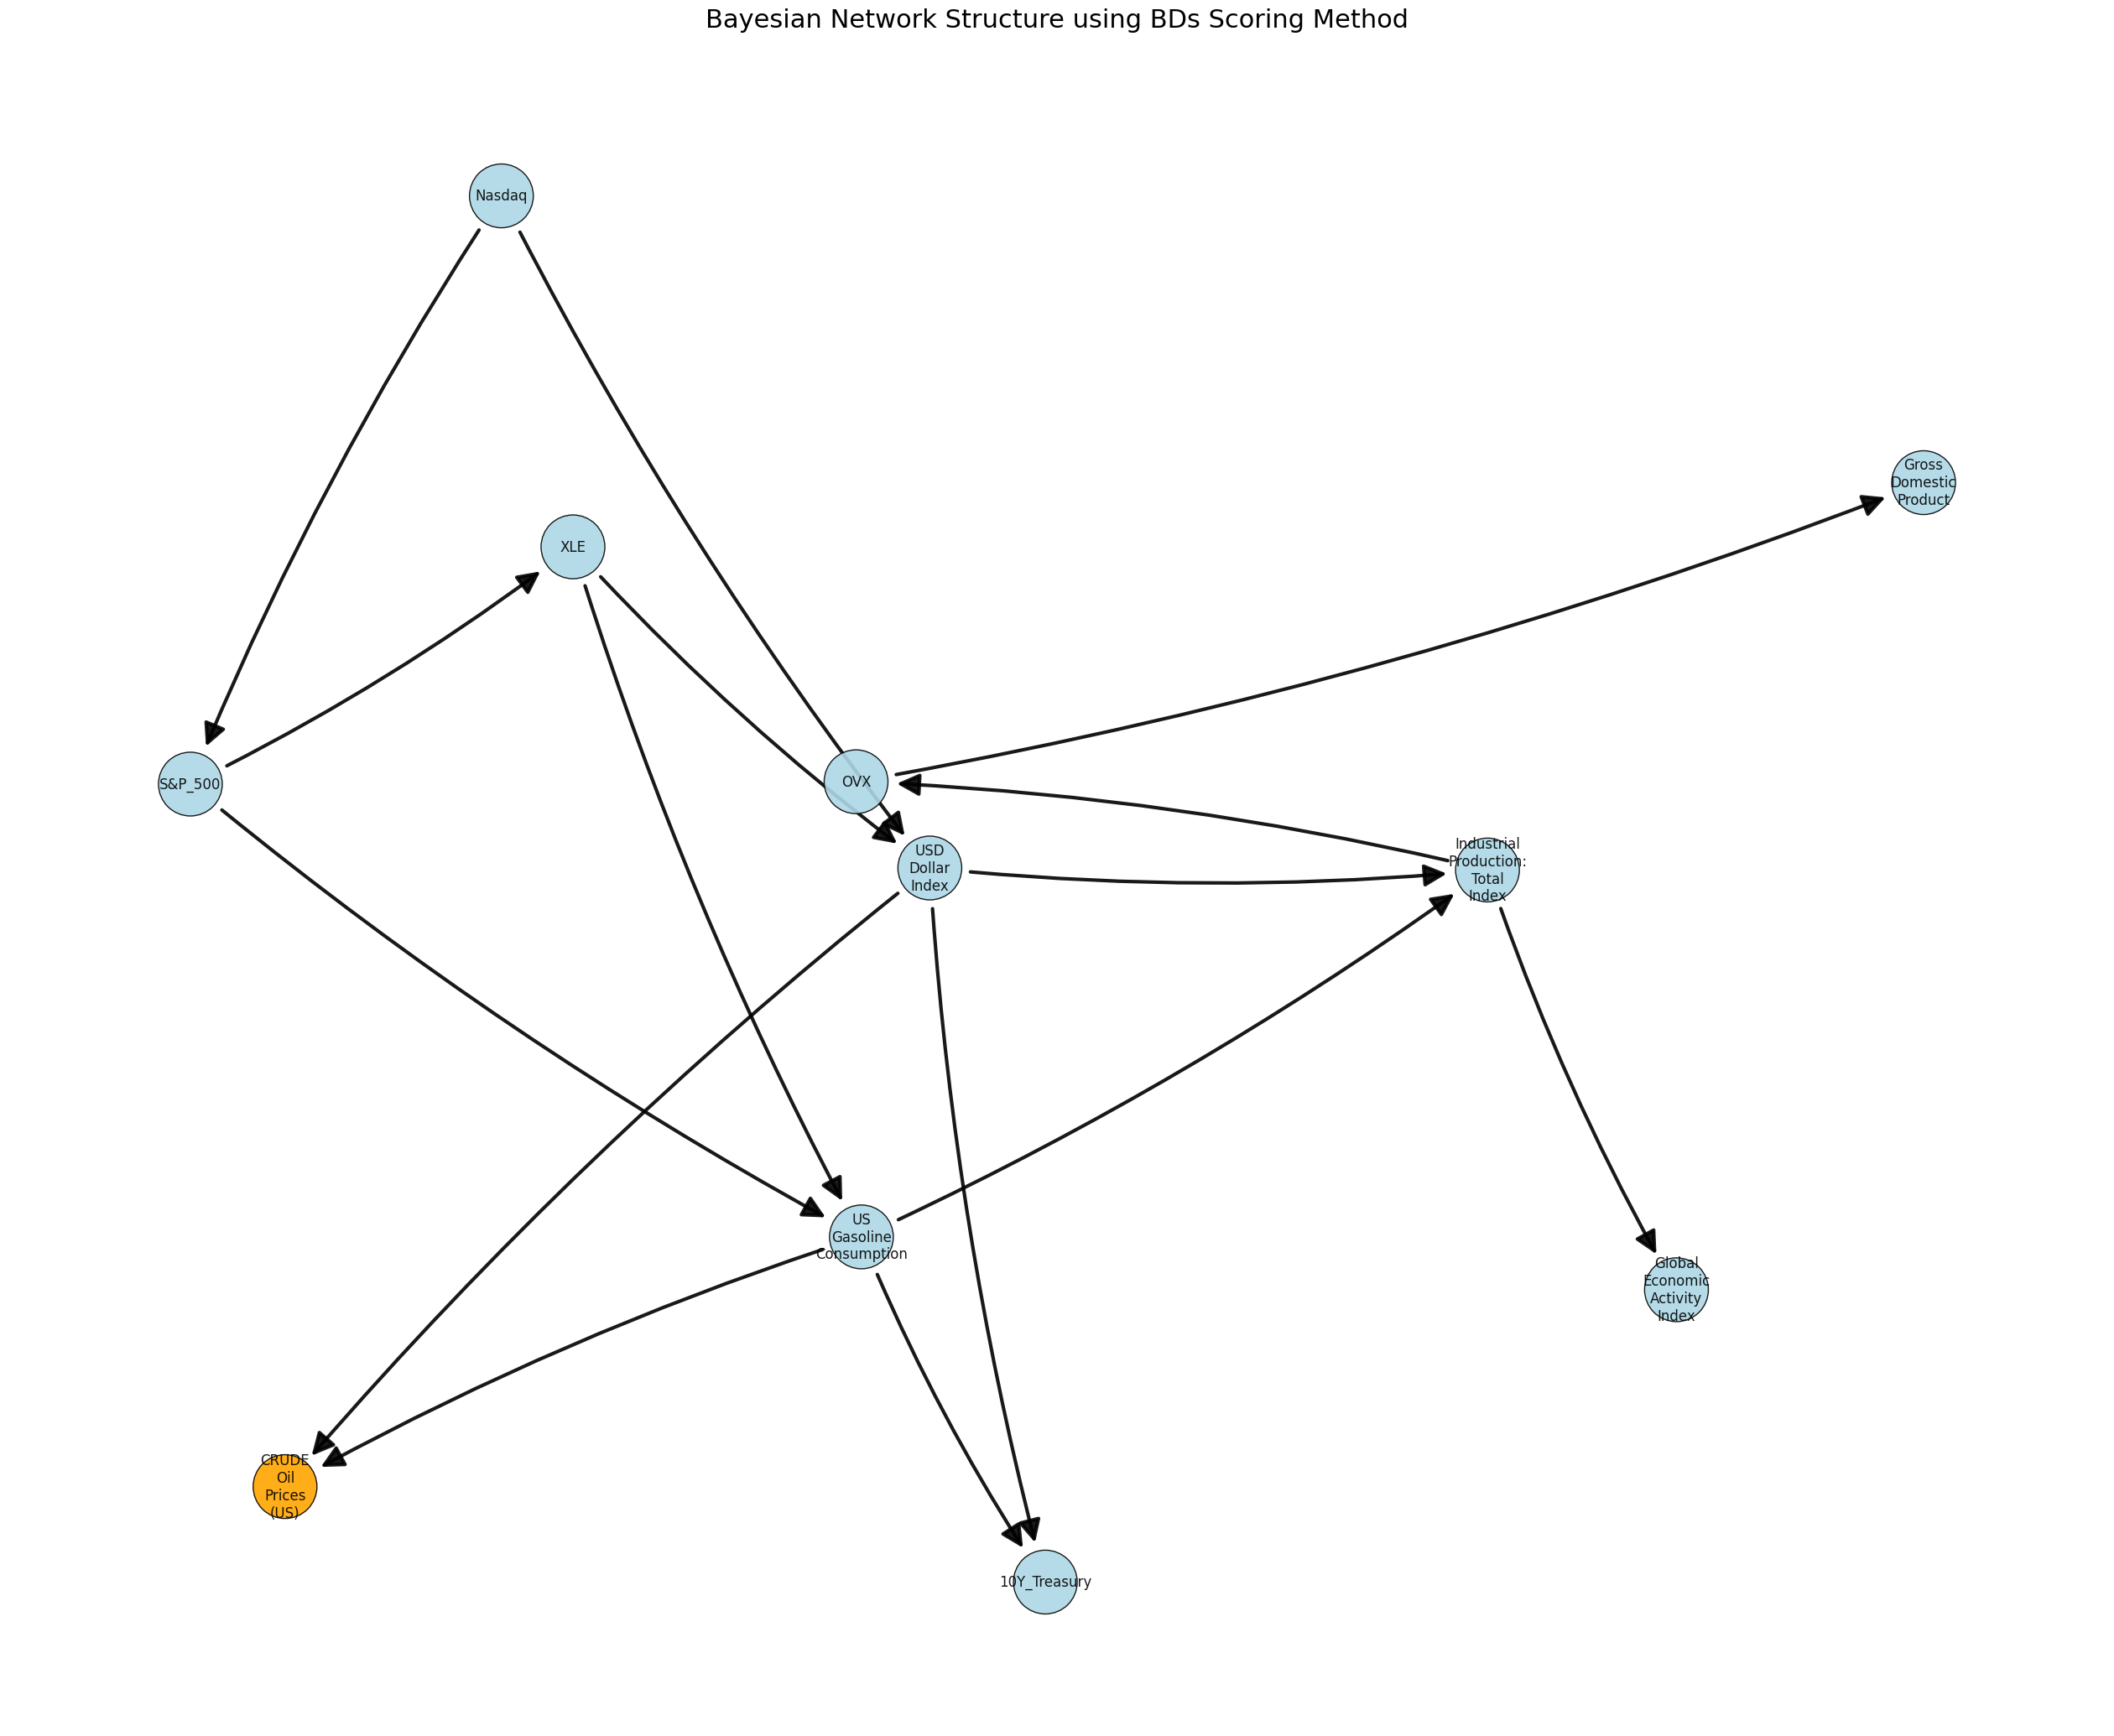

In [ ]:
for name, edges in learned_edges_dict.items():
    G = nx.DiGraph(list(edges))

    plt.figure(figsize=(25, 20))
    pos = nx.spring_layout(G, k=1.0, iterations=50)

    node_names = {n: '\n'.join(n.split(' ')) for n in G.nodes()}

    node_colors = []
    for node in G.nodes():
        if node == 'CRUDE Oil Prices (US)':
            node_colors.append('orange')
        else:
            node_colors.append('lightblue')

    nx.draw(G, pos,
            node_size=3000,
            with_labels=True,
            labels=node_names,
            node_color=node_colors,
            edgecolors='black',
            linewidths=1,
            arrowstyle='-|>',
            arrowsize=40,
            width=3,
            edge_color='black',
            alpha=0.9,
            connectionstyle='arc3,rad=0.05',
            min_source_margin=35,
            min_target_margin=35
    )

    plt.title(f'Bayesian Network Structure using {name} Scoring Method', fontsize=22, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### Model Validation

In [ ]:
def evaluate_pgm_models(data_df, target_variable, learned_pgm_models_dict, data_name):
    accuracies_dict = {}
    all_actual_states = []
    all_predicted_states = {name: [] for name in learned_pgm_models_dict.keys() if name != 'K2'}

    for name, model_structure_dag in learned_pgm_models_dict.items():

        print(f"\nEvaluating model learned with {name} on {data_name} Data")

        model_with_cpds = DiscreteBayesianNetwork(model_structure_dag.edges())
        model_with_cpds.fit(hidden_states_df, estimator=BayesianEstimator);

        actual_states = []
        predicted_states = []

        parents_of_target = list(model_with_cpds.get_parents(target_variable))
        infer = VariableElimination(model_with_cpds)

        for index, row in data_df.iterrows():
            actual_state_val = row[target_variable]
            actual_states.append(actual_state_val)

            evidence = {}
            for parent in parents_of_target:
                if parent in row.index:
                    evidence[parent] = row[parent]

            if evidence:
                query_result = infer.query(variables=[target_variable], evidence=evidence, show_progress=False)
                if len(query_result.values) > 0:
                    predicted_state = np.argmax(query_result.values)
                    predicted_states.append(predicted_state)
                else:
                    predicted_states.append(np.nan)
            else:
                marginal_dist = infer.query(variables=[target_variable], show_progress=False)
                if len(marginal_dist.values) > 0:
                    predicted_state = np.argmax(marginal_dist.values)
                    predicted_states.append(predicted_state)
                else:
                    predicted_states.append(np.nan)

        clean_actual_states = [actual for actual, pred in zip(actual_states, predicted_states) if not np.isnan(pred)]
        clean_predicted_states = [pred for pred in predicted_states if not np.isnan(pred)]

        if clean_actual_states:
            accuracy = accuracy_score(clean_actual_states, clean_predicted_states)
            print(f"Accuracy for {name} model on {len(clean_actual_states)} {data_name} predictions: {accuracy:.4f}")
        else:
            accuracy = 0.0
            print(f"Could not calculate accuracy for {name} on {data_name} data")

        accuracies_dict[name] = {
            'accuracy': accuracy,
            'actual_states': clean_actual_states,
            'predicted_states': clean_predicted_states
        }
        if not all_actual_states:
            all_actual_states = clean_actual_states
        all_predicted_states[name] = clean_predicted_states

    combined_results_df = pd.DataFrame({'Actual States': all_actual_states})
    for name, preds in all_predicted_states.items():
        combined_results_df[f'Predicted ({name})'] = preds

    return accuracies_dict, combined_results_df


Use `val_data` for validation, use models already trained to do predictions on validation data and models on `hmm_models`

In [ ]:
all_hidden_states_val = {}

 # Prepare the differenced series for prediction from validation data
for column_name, model in hmm_models.items():
    X_series_diff_val = val_data[column_name].diff().dropna().values.reshape(-1, 1)
    hidden_states_array_val = model.predict(X_series_diff_val)
    all_hidden_states_val[column_name] = hidden_states_array_val


In [ ]:
hidden_states_df_val = pd.DataFrame()
for column_name, hidden_states_array in all_hidden_states_val.items():
    dates_for_states = val_data[column_name].iloc[1:].index
    if len(dates_for_states) == len(hidden_states_array):
        hidden_states_df_val[column_name] = pd.Series(hidden_states_array, index=dates_for_states)
    else:
        print(f"Mismatch in length for {column_name}: dates {len(dates_for_states)}, states {len(hidden_states_array)}")

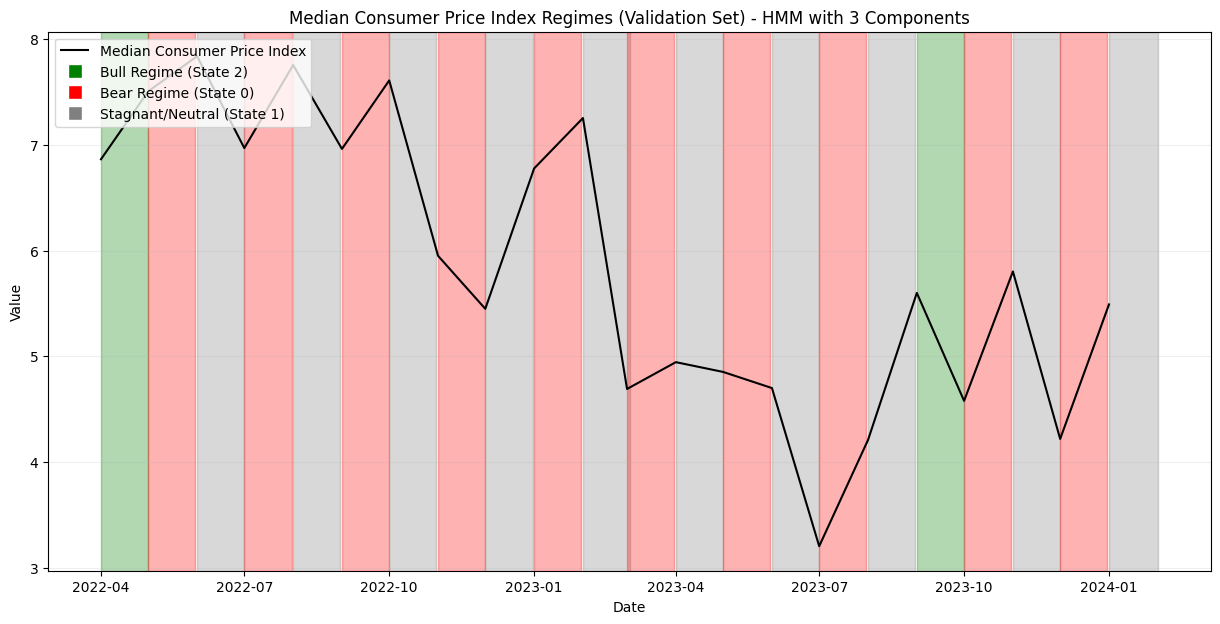

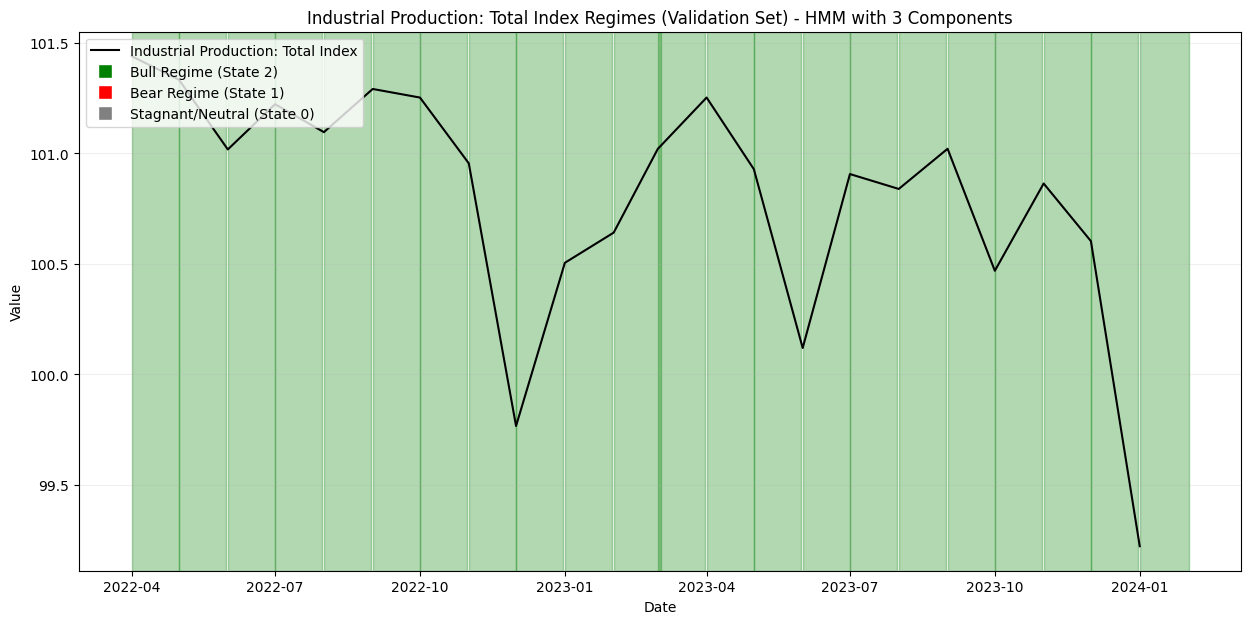

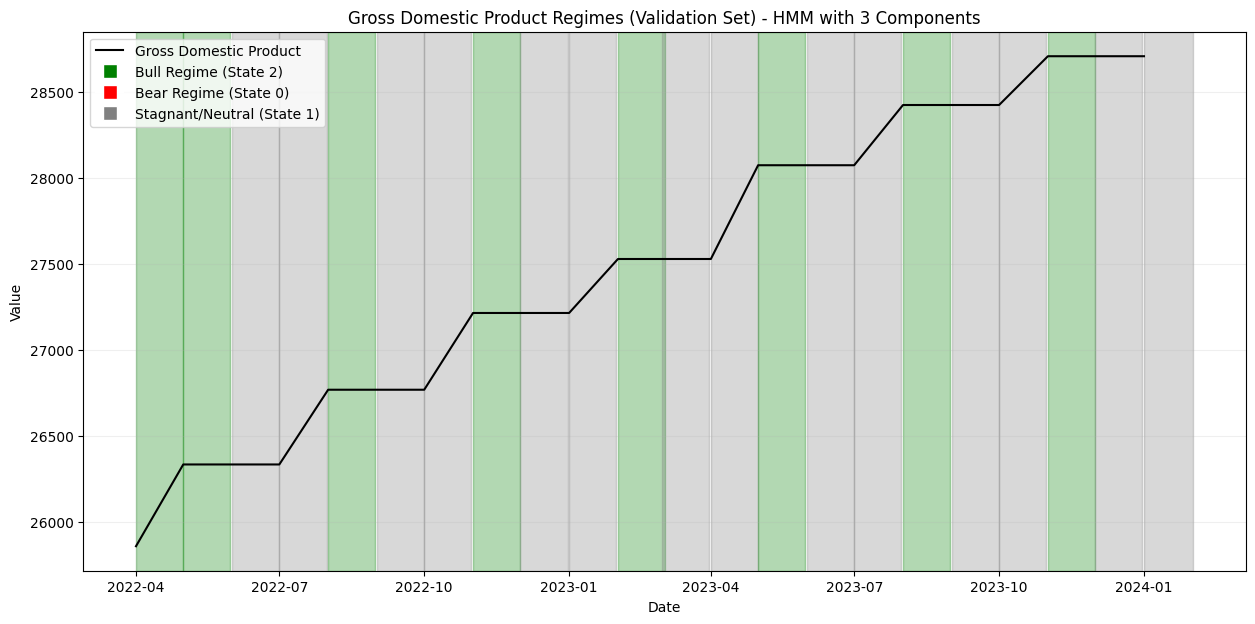

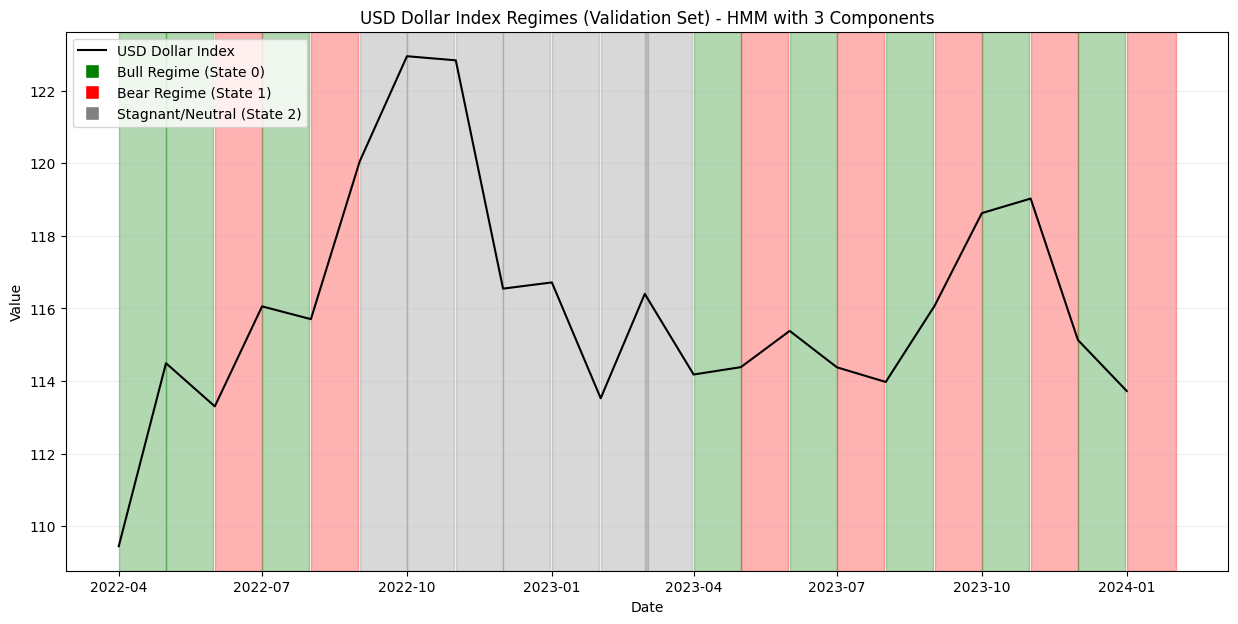

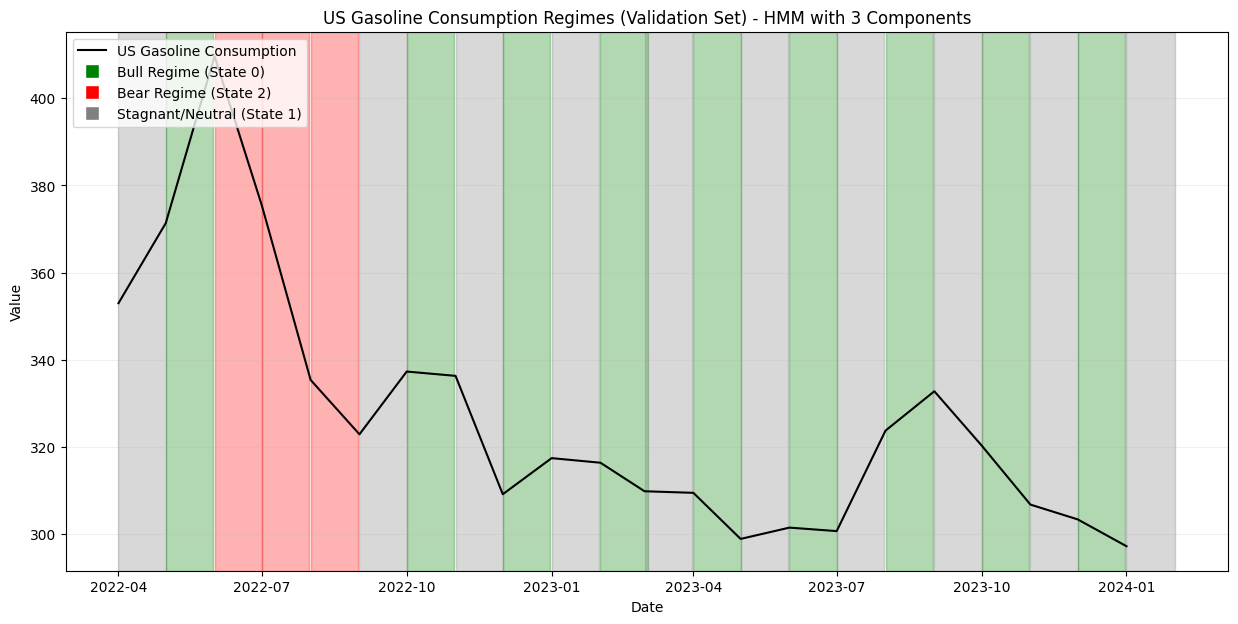

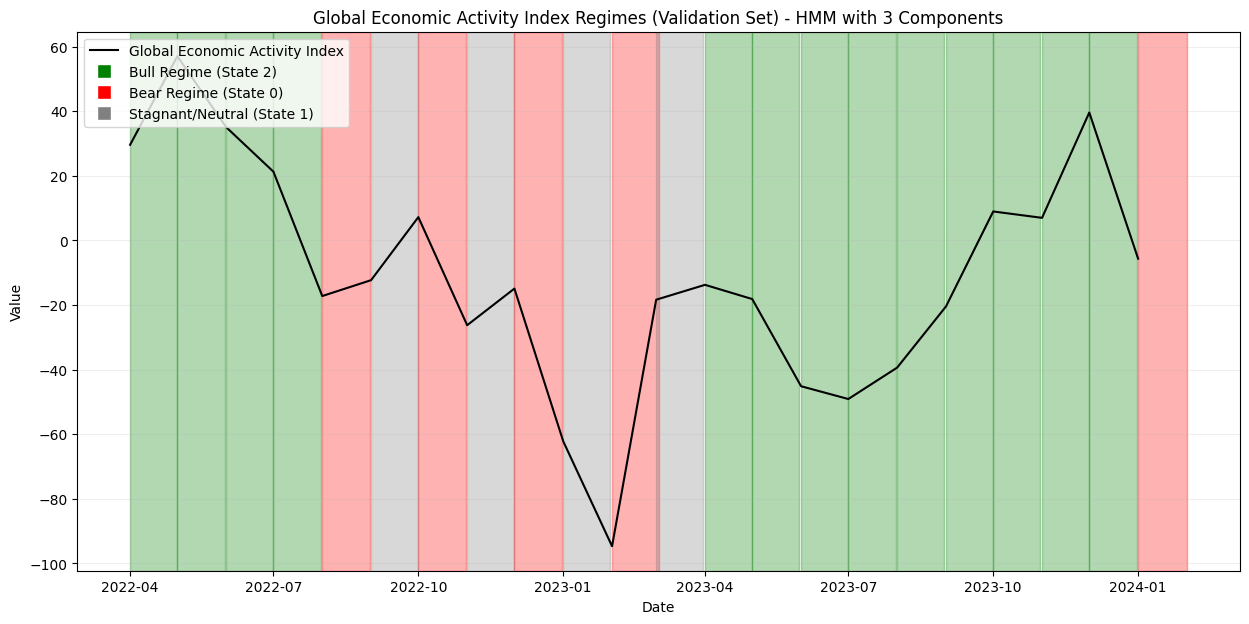

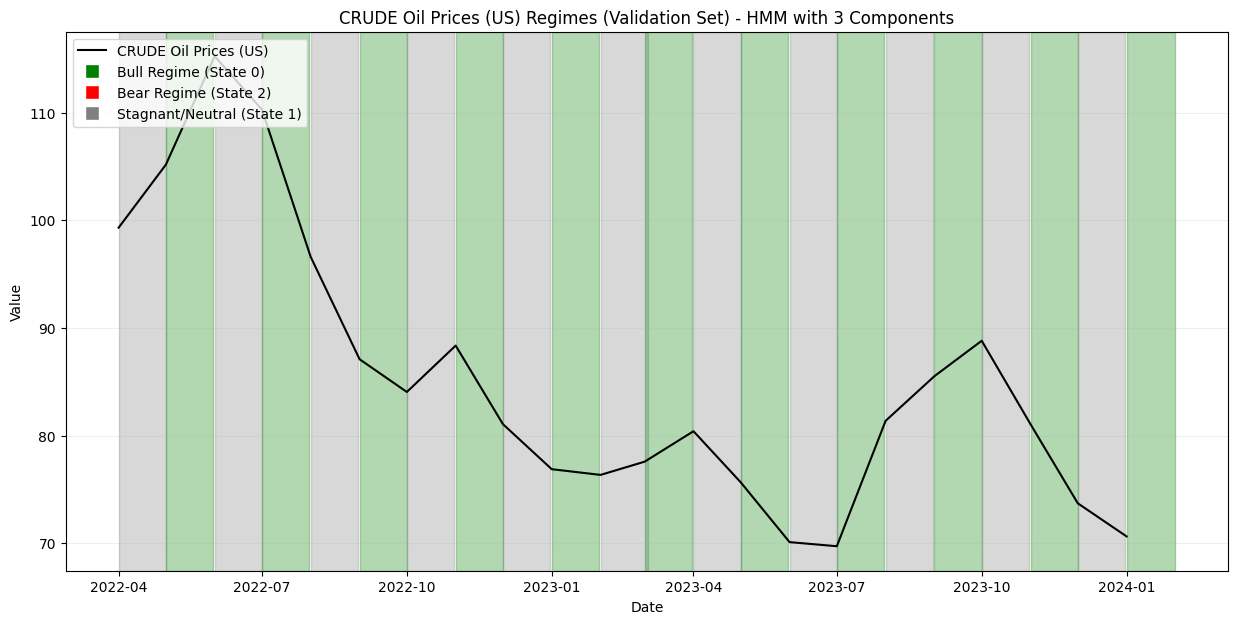

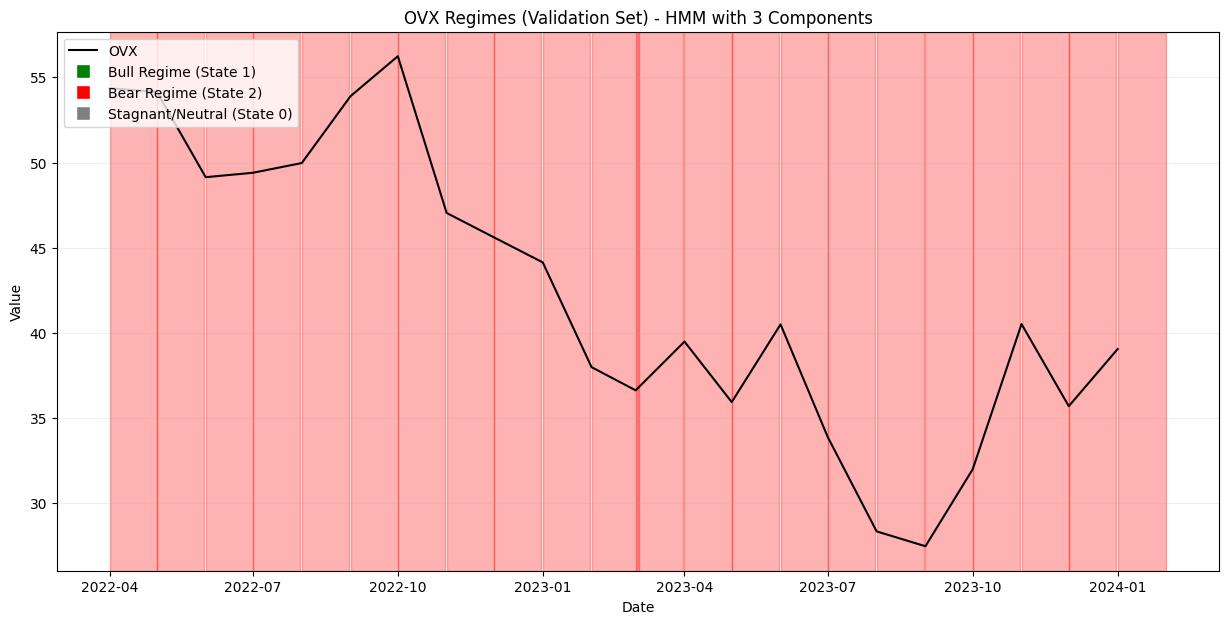

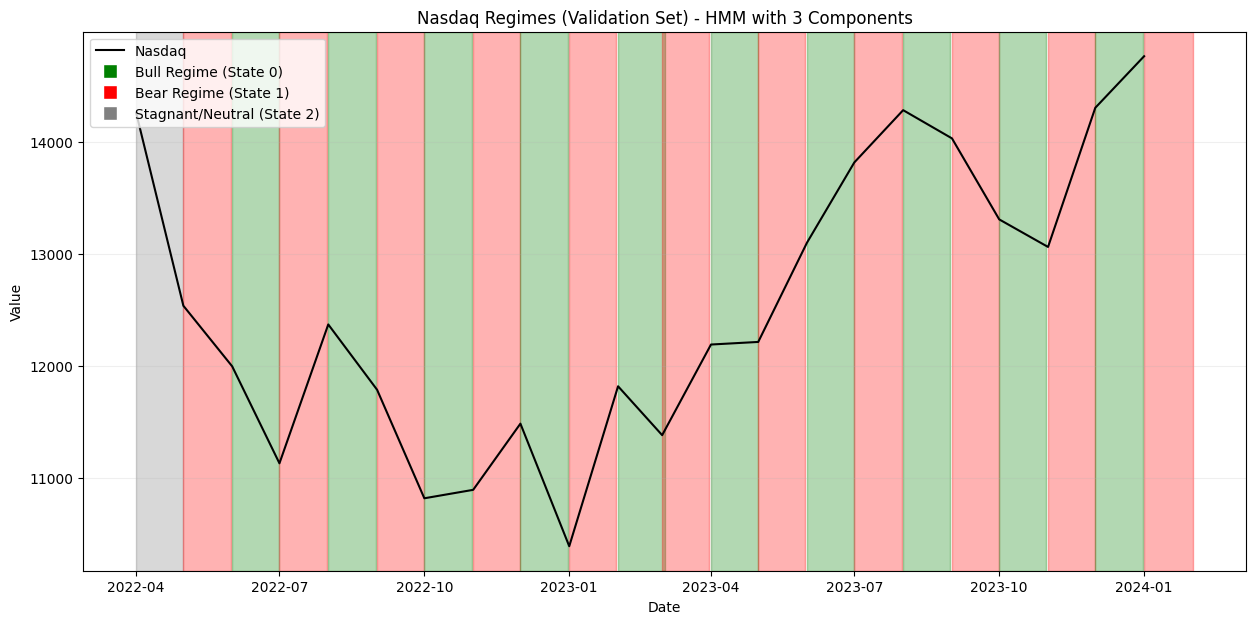

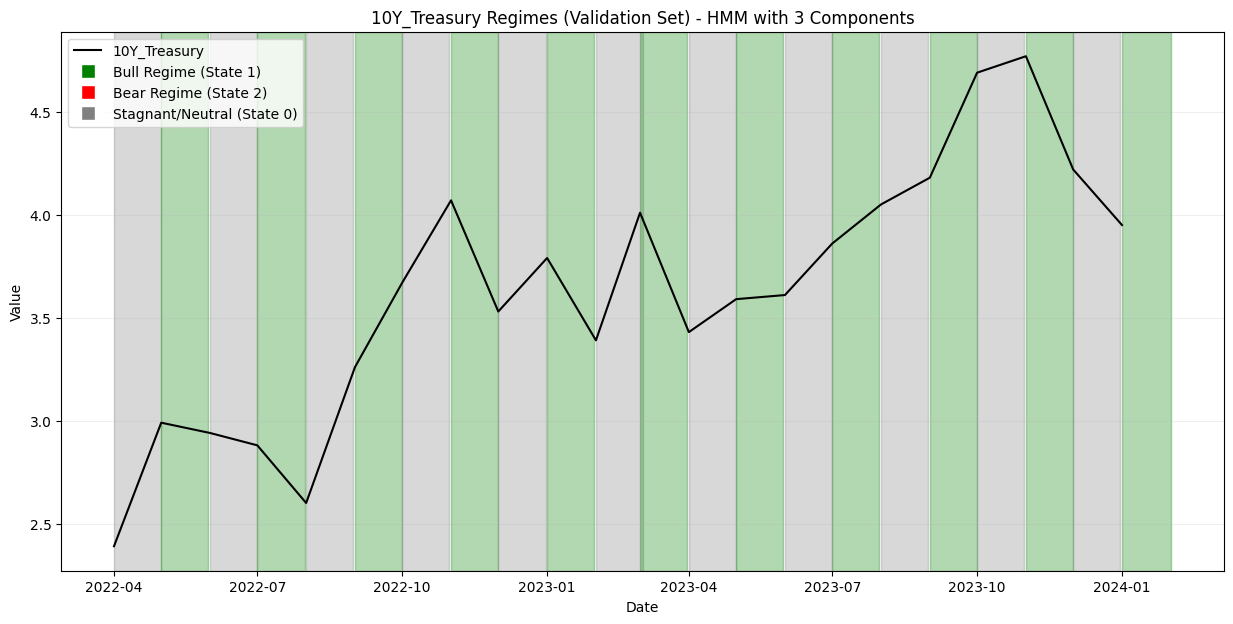

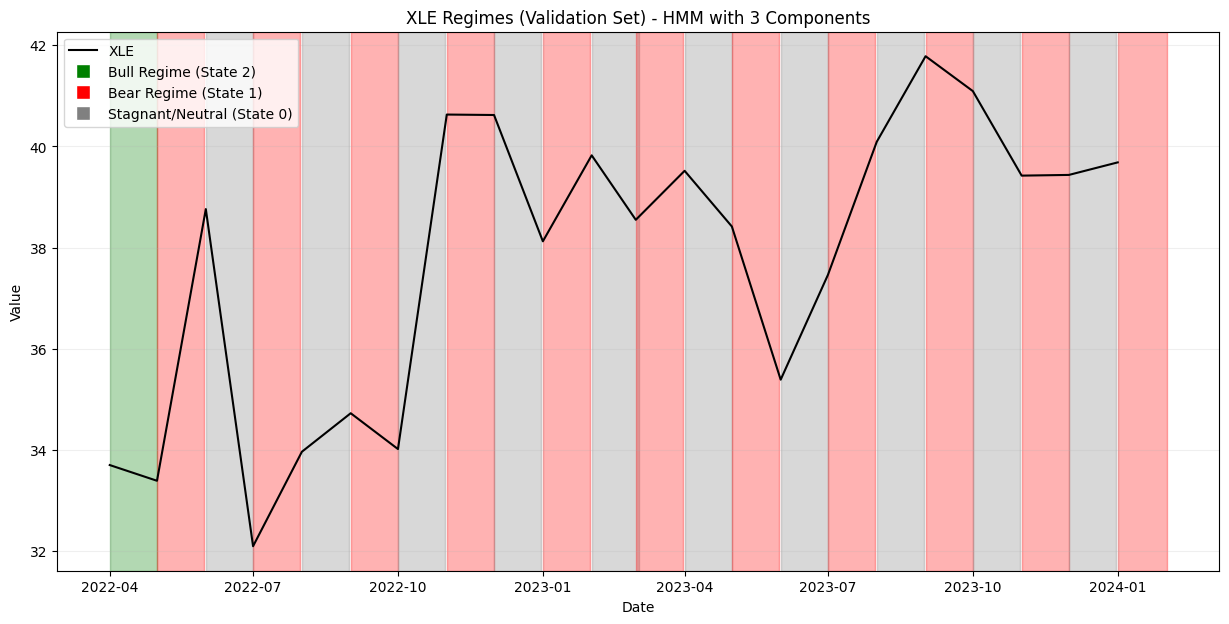

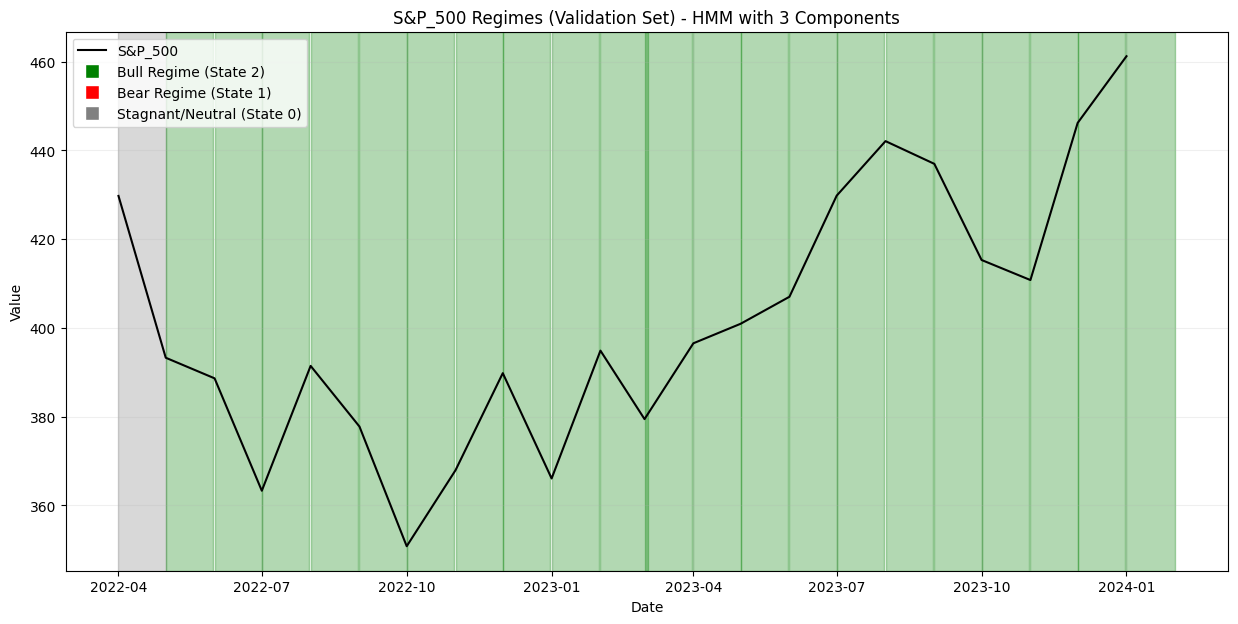

In [ ]:
for column_name in hidden_states_df_val.columns:

    hidden_states_val = hidden_states_df_val[column_name]
    original_series_val = val_data[column_name].iloc[1:]

    # Ensure dates align with hidden states
    dates_for_plot_val = original_series_val.index

    # Retrieve state mapping for this variable
    states_map = hmm_states_mapping.get(column_name, {})
    bear_state = states_map.get('bear_state')
    bull_state = states_map.get('bull_state')
    stagnant_state = states_map.get('stagnant_state')

    plt.figure(figsize=(15, 7))
    plt.plot(dates_for_plot_val, original_series_val, color='black', lw=1.5, label=f'{column_name} Value')

    # Color regime
    for i in range(len(hidden_states_val)):
        if i < len(dates_for_plot_val):
            state = hidden_states_val.iloc[i]
            color = 'green' if state == bull_state else ('red' if state == bear_state else 'gray')


            start_date = dates_for_plot_val[i]
            end_date = dates_for_plot_val[i] + pd.Timedelta(days=30)

            if i == len(dates_for_plot_val) - 1 and len(dates_for_plot_val) > 1:
                end_date = dates_for_plot_val[i] + (dates_for_plot_val[i] - dates_for_plot_val[i-1])

            plt.axvspan(start_date, end_date, color=color, alpha=0.3)

    # Update legend elements to include state indices
    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, label=f'{column_name}'),
        Line2D([0], [0], marker='s', color='w', label=f'Bull Regime (State {bull_state})', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='s', color='w', label=f'Bear Regime (State {bear_state})', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label=f'Stagnant/Neutral (State {stagnant_state})', markerfacecolor='gray', markersize=10)
    ]

    plt.title(f'{column_name} Regimes (Validation Set) - HMM with 3 Components')
    plt.ylabel('Value')
    plt.xlabel('Date')
    plt.legend(handles=legend_elements, loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

In [ ]:
display(hidden_states_df_val.head())

,Median Consumer Price Index,Industrial Production: Total Index,Gross Domestic Product,USD Dollar Index,US Gasoline Consumption,Global Economic Activity Index,CRUDE Oil Prices (US),OVX,Nasdaq,10Y_Treasury,XLE,S&P_500
2022-04-01,2,2,2,0,1,2,1,2,2,0,2,0
2022-05-01,0,2,2,0,0,2,0,2,1,1,1,2
2022-06-01,1,2,1,1,2,2,1,2,0,0,0,2
2022-07-01,0,2,1,0,2,2,0,2,1,1,1,2
2022-08-01,1,2,2,1,2,0,1,2,0,0,0,2


In [ ]:
target_variable = 'CRUDE Oil Prices (US)'

# Evaluate on Validation Data
val_accuracies, combined_val_results_df = evaluate_pgm_models(
    hidden_states_df_val, target_variable, learned_pgm_models_dict, 'Validation'
)
display(combined_val_results_df.head(10))


Evaluating model learned with BIC on Validation Data
Accuracy for BIC model on 22 Validation predictions: 0.0909

Evaluating model learned with K2 on Validation Data
Accuracy for K2 model on 22 Validation predictions: 0.5455

Evaluating model learned with BDeu on Validation Data
Accuracy for BDeu model on 22 Validation predictions: 0.5455

Evaluating model learned with BDs on Validation Data
Accuracy for BDs model on 22 Validation predictions: 0.4091


,Actual States,Predicted (BIC),Predicted (BDeu),Predicted (BDs),Predicted (K2)
0,1,1,1,1,1
1,0,0,0,0,0
2,1,2,0,0,0
3,0,2,0,2,0
4,1,2,0,0,0
5,0,1,0,0,0
6,1,0,0,1,0
7,0,1,0,0,0
8,1,0,0,1,0
9,0,1,0,0,0


### Prediction using models

In [ ]:
accuracies = {}
target_variable = 'CRUDE Oil Prices (US)'

Use models already used in `learned_pgm_models_dict`

### Model Testing

In [ ]:
all_hidden_states_test = {}

for column_name, model in hmm_models.items():
    # Prepare the differenced series for prediction from test data
    X_series_diff_test = test_data[column_name].diff().dropna().values.reshape(-1, 1)

    if len(X_series_diff_test) > 0:
        hidden_states_array_test = model.predict(X_series_diff_test)
        all_hidden_states_test[column_name] = hidden_states_array_test
    else:
        print(f"Skipping {column_name} in test data due to insufficient data after differencing.")

In [ ]:
hidden_states_df_test = pd.DataFrame()
for column_name, hidden_states_array in all_hidden_states_test.items():
    dates_for_states = test_data[column_name].iloc[1:].index
    if len(dates_for_states) == len(hidden_states_array):
        hidden_states_df_test[column_name] = pd.Series(hidden_states_array, index=dates_for_states)
    else:
        print(f"Mismatch in length for {column_name} in test data: dates {len(dates_for_states)}, states {len(hidden_states_array)}")

display(hidden_states_df_test.head())

,Median Consumer Price Index,Industrial Production: Total Index,Gross Domestic Product,USD Dollar Index,US Gasoline Consumption,Global Economic Activity Index,CRUDE Oil Prices (US),OVX,Nasdaq,10Y_Treasury,XLE,S&P_500
2024-03-01,2,2,2,0,1,2,1,2,2,0,2,0
2024-04-01,0,2,1,1,0,2,0,2,2,1,1,1
2024-05-01,1,2,2,0,1,2,1,2,1,0,0,2
2024-06-01,0,2,1,1,0,2,0,2,0,1,1,2
2024-07-01,1,2,1,0,1,2,1,2,1,0,2,2


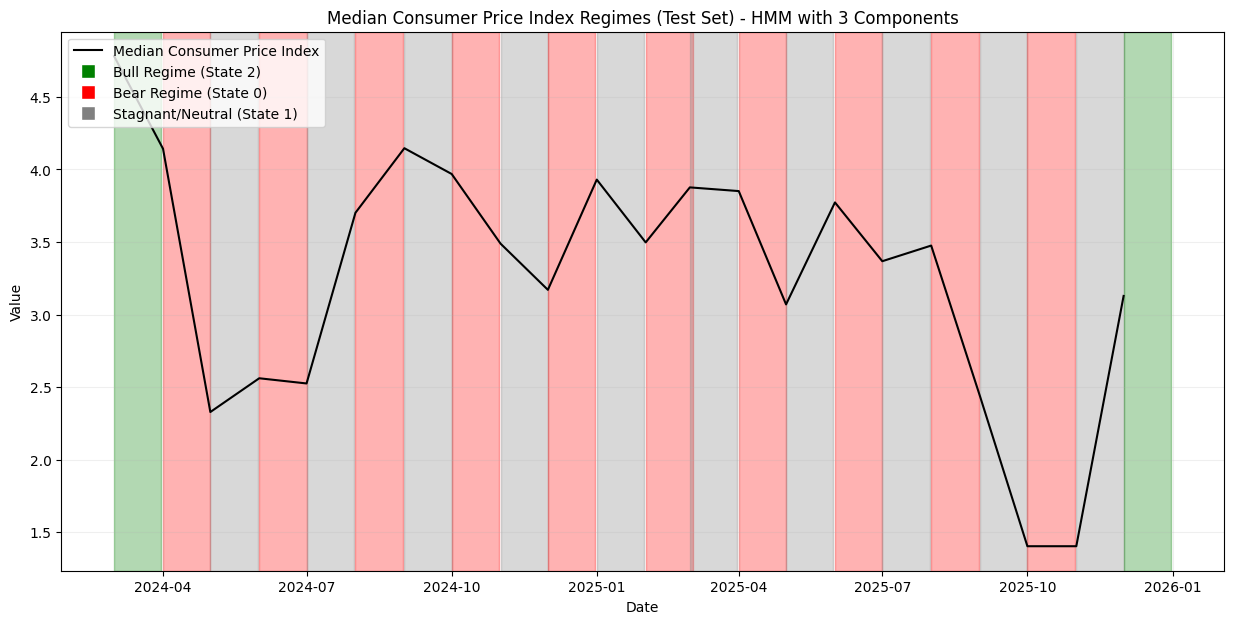

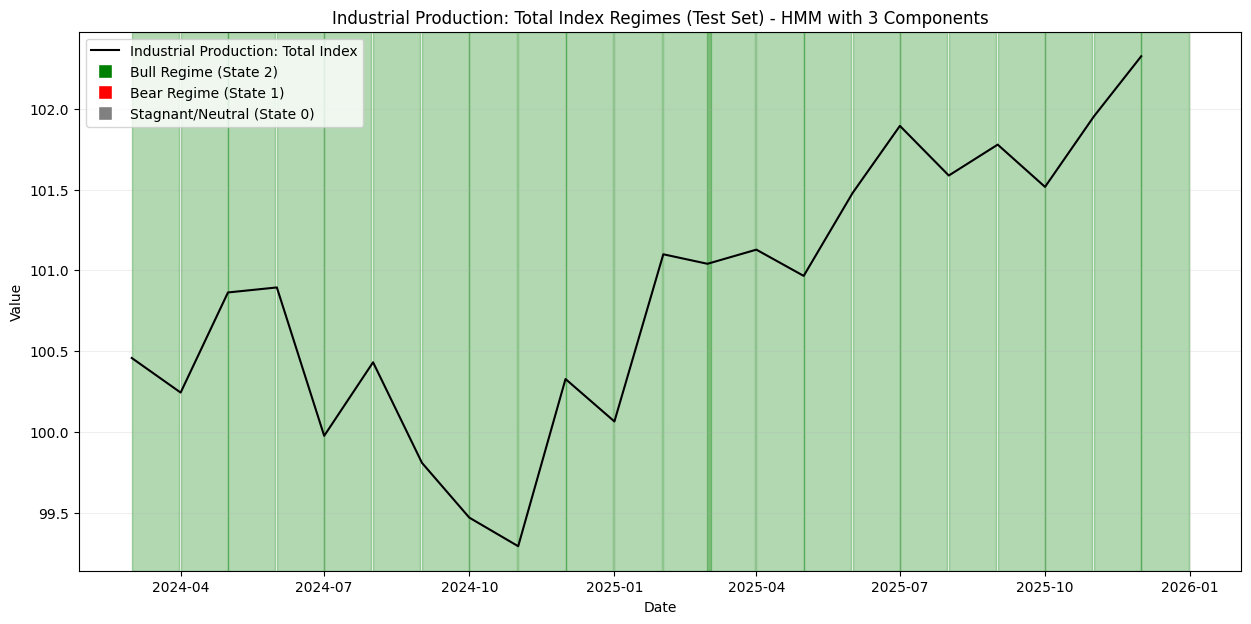

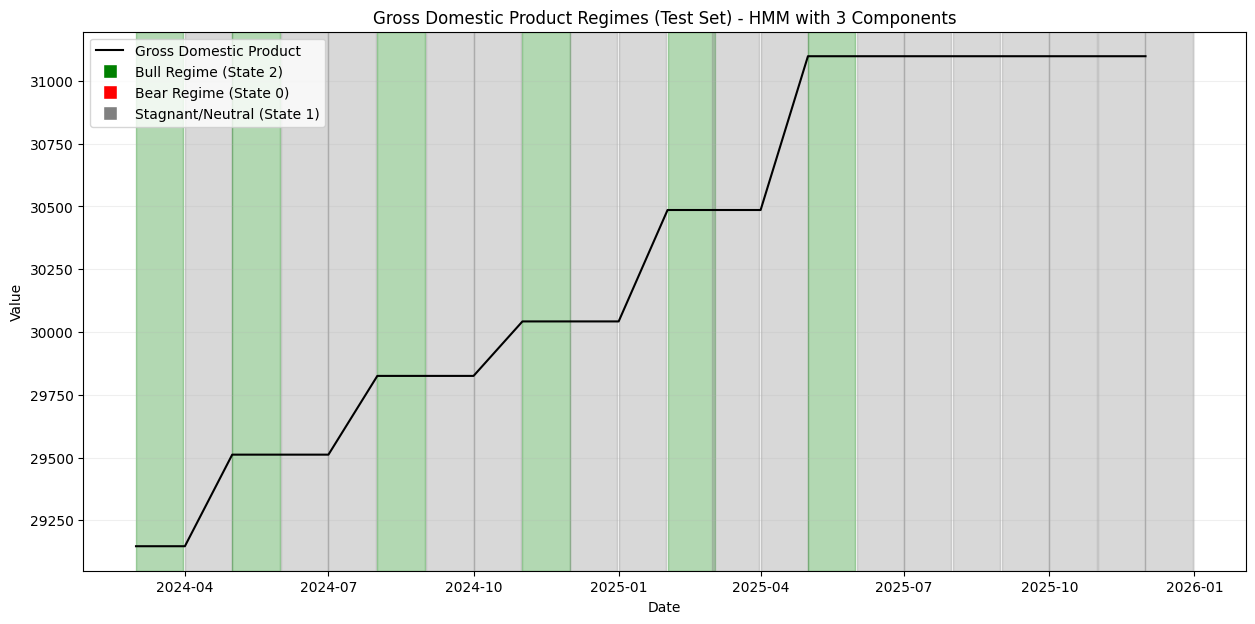

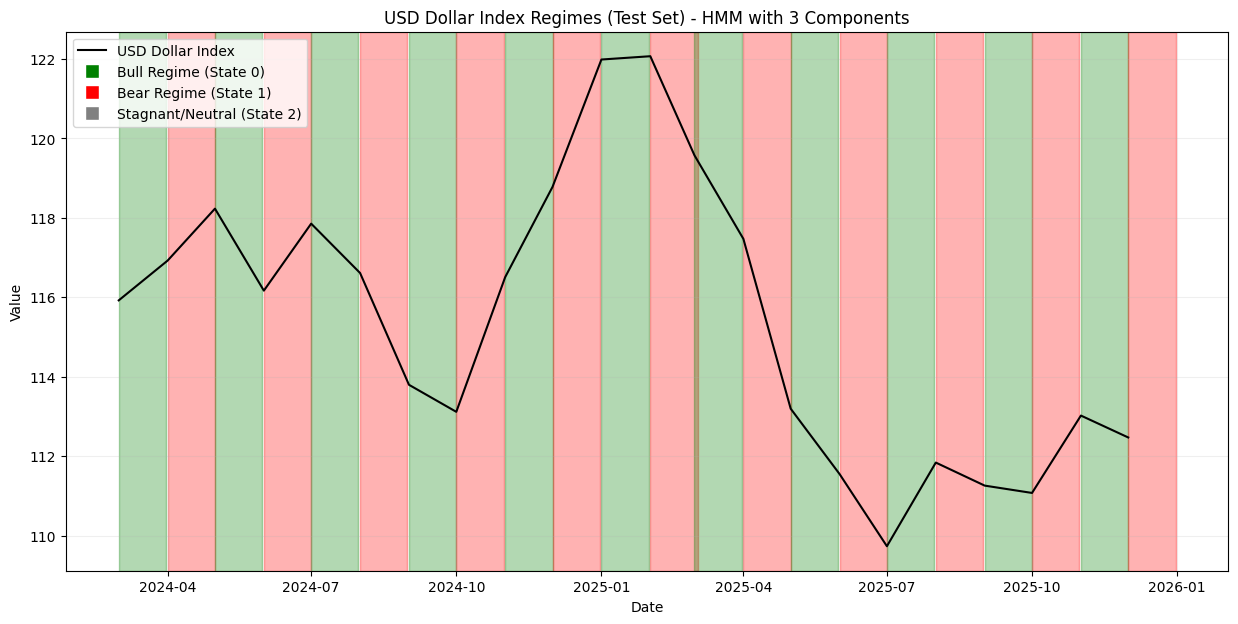

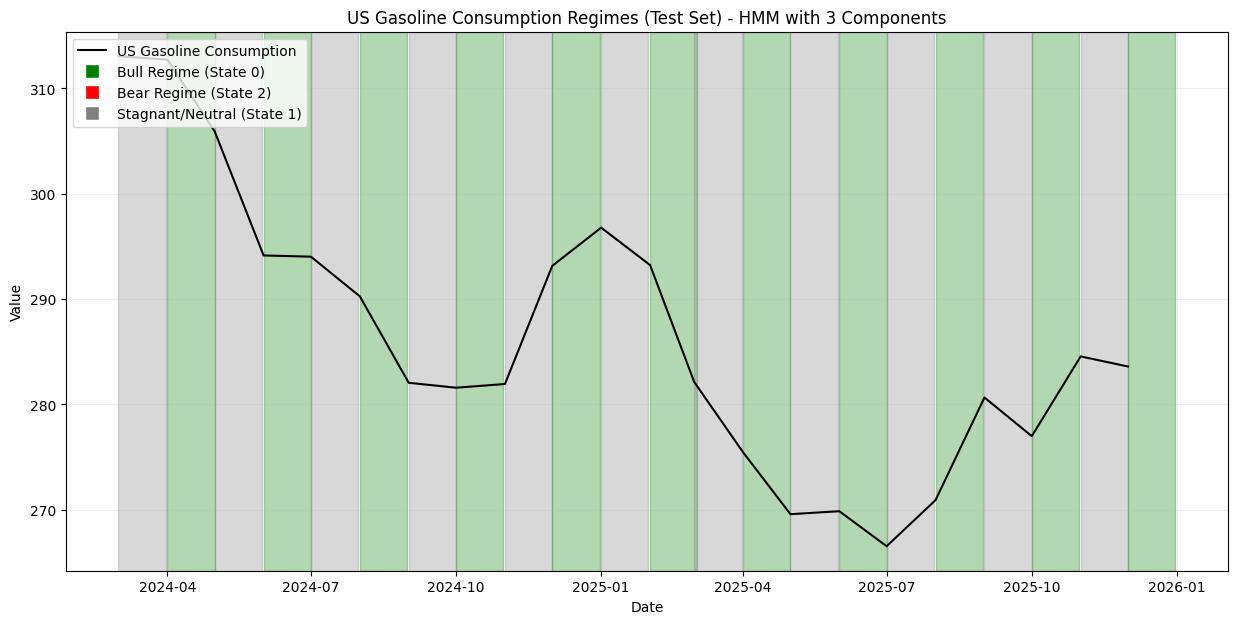

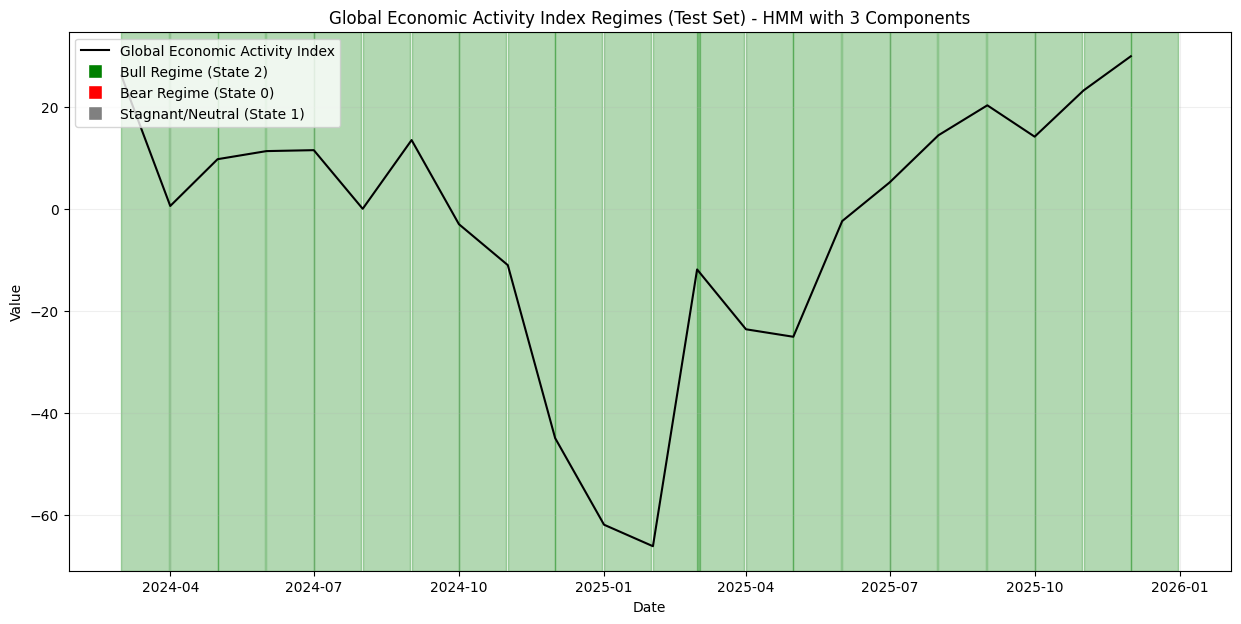

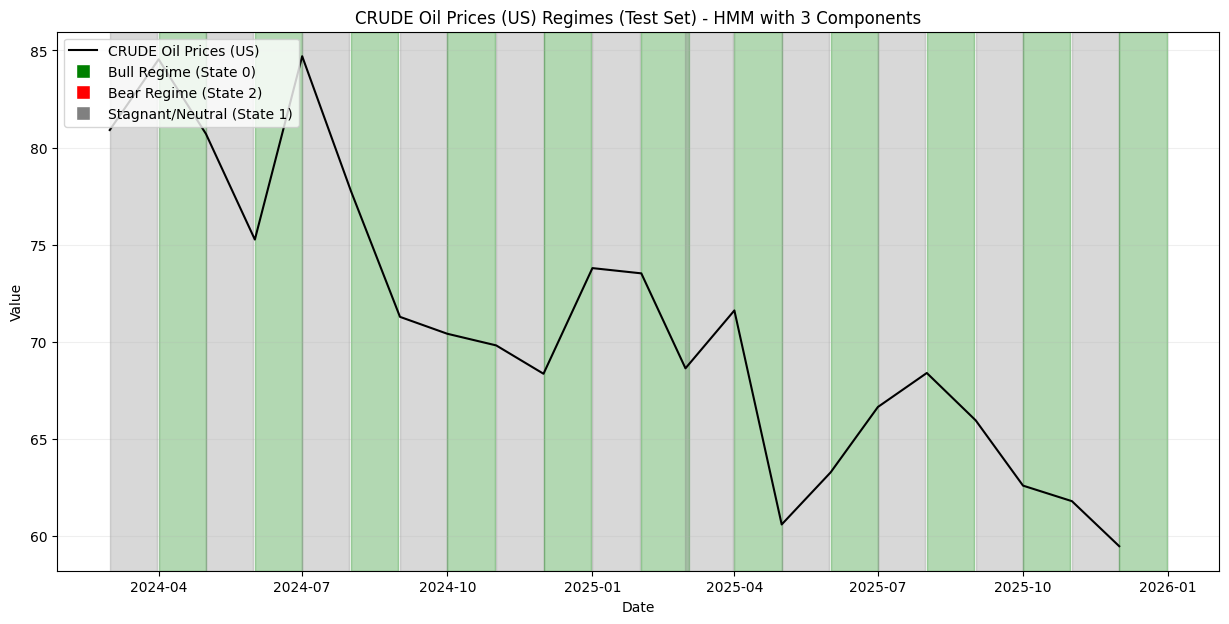

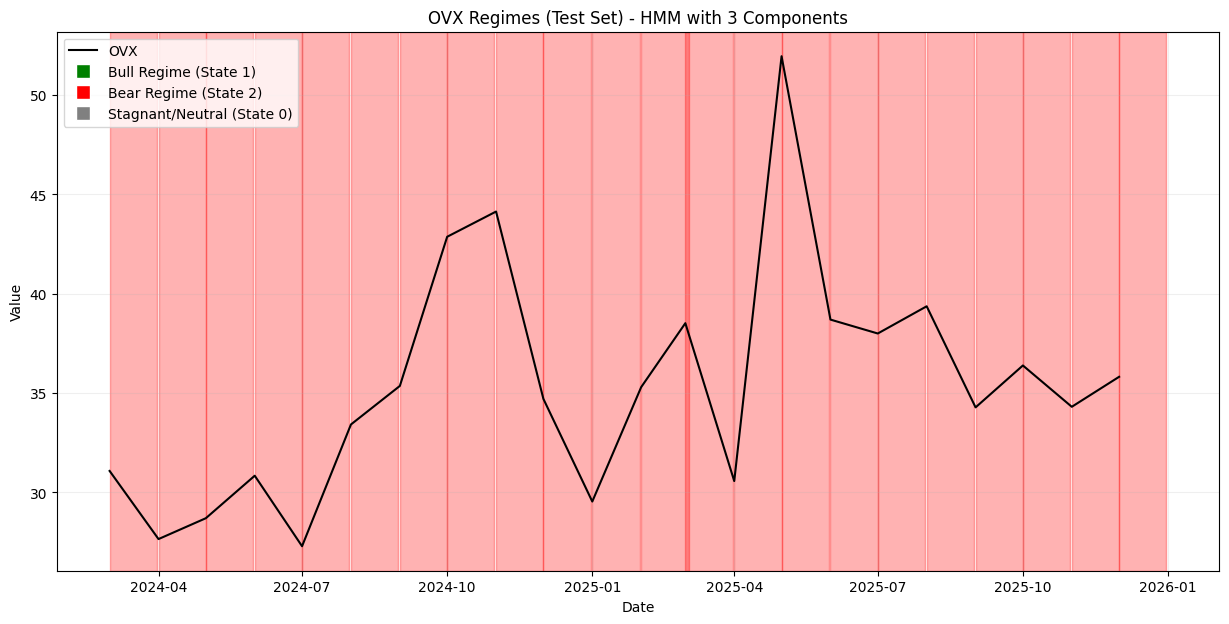

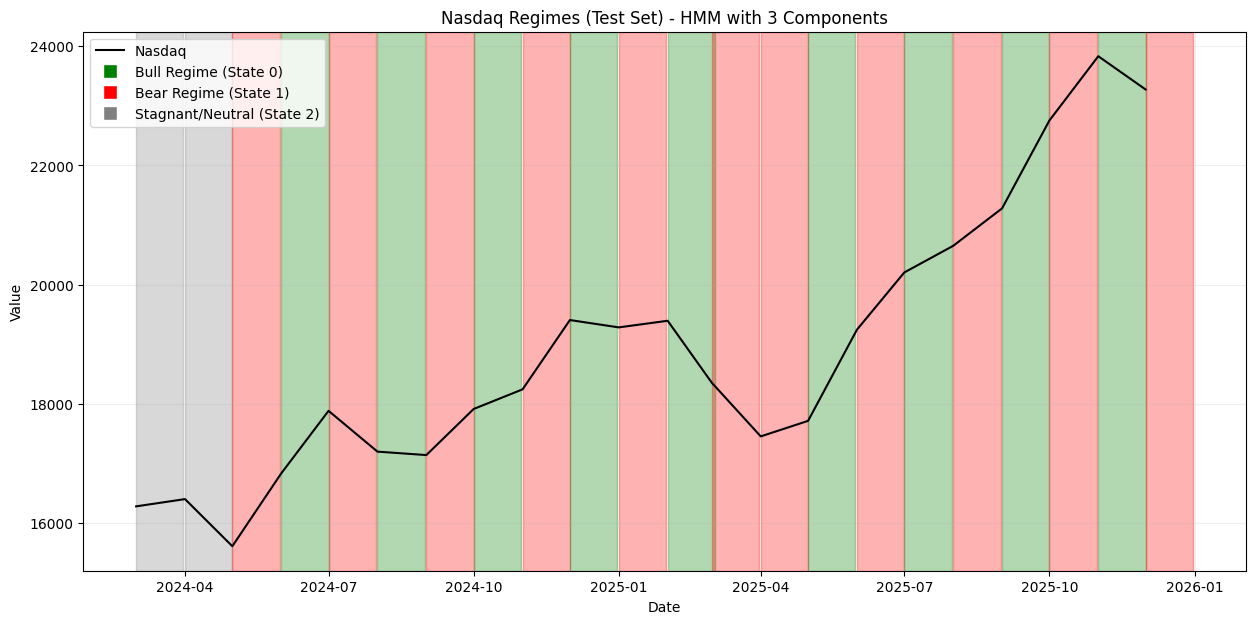

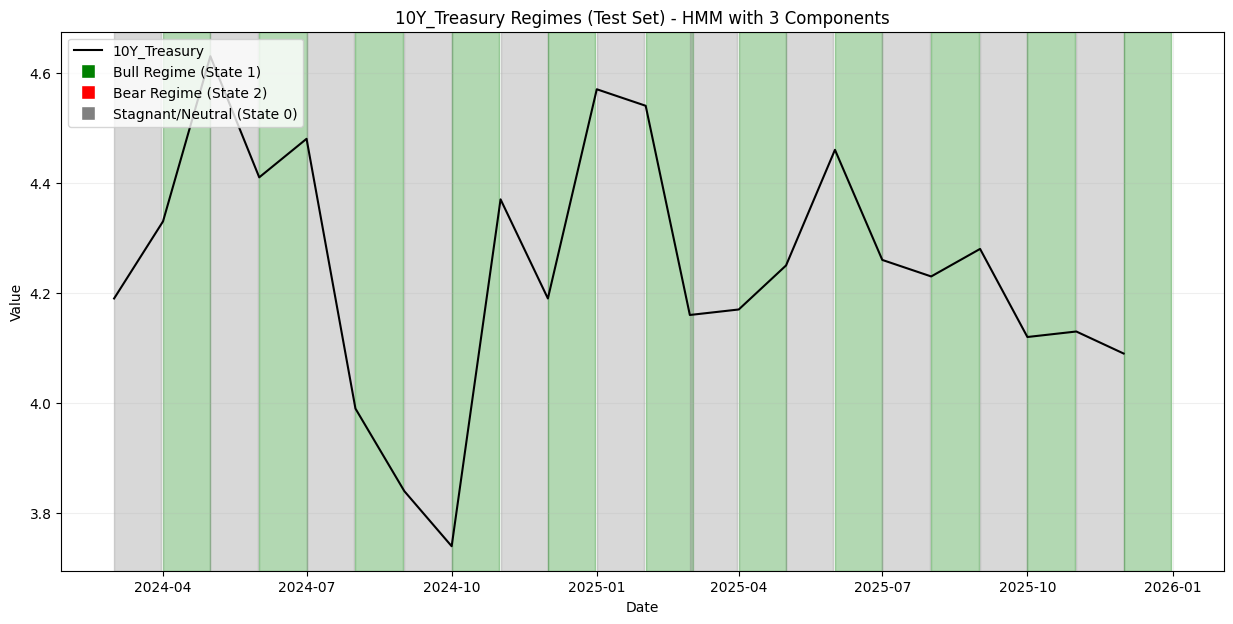

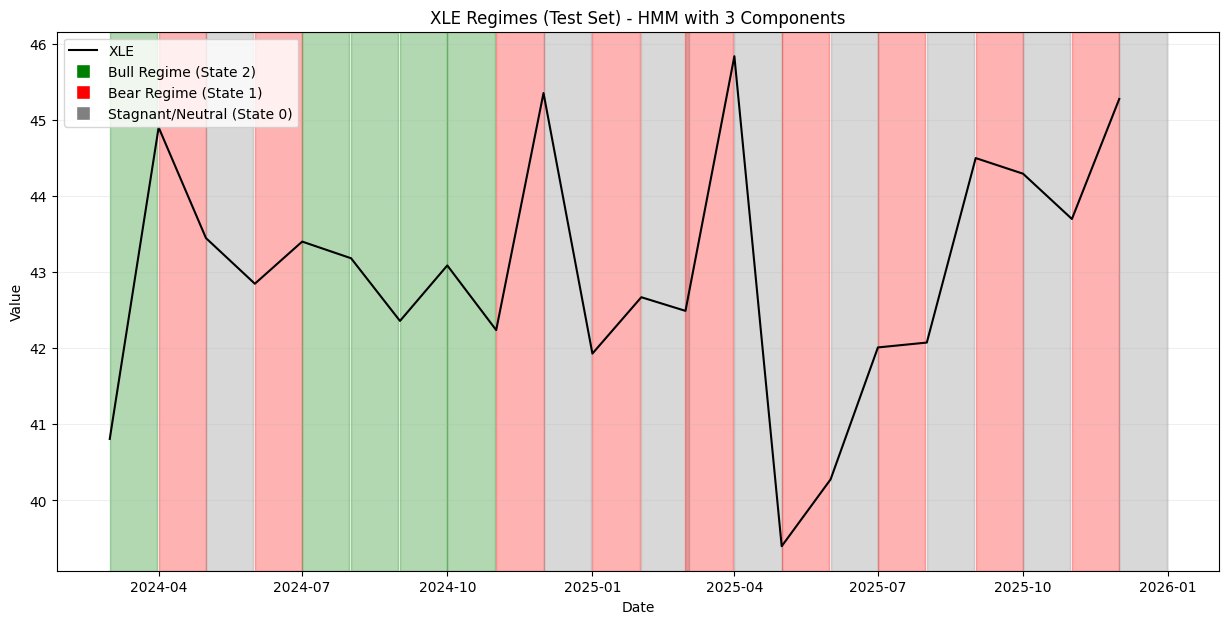

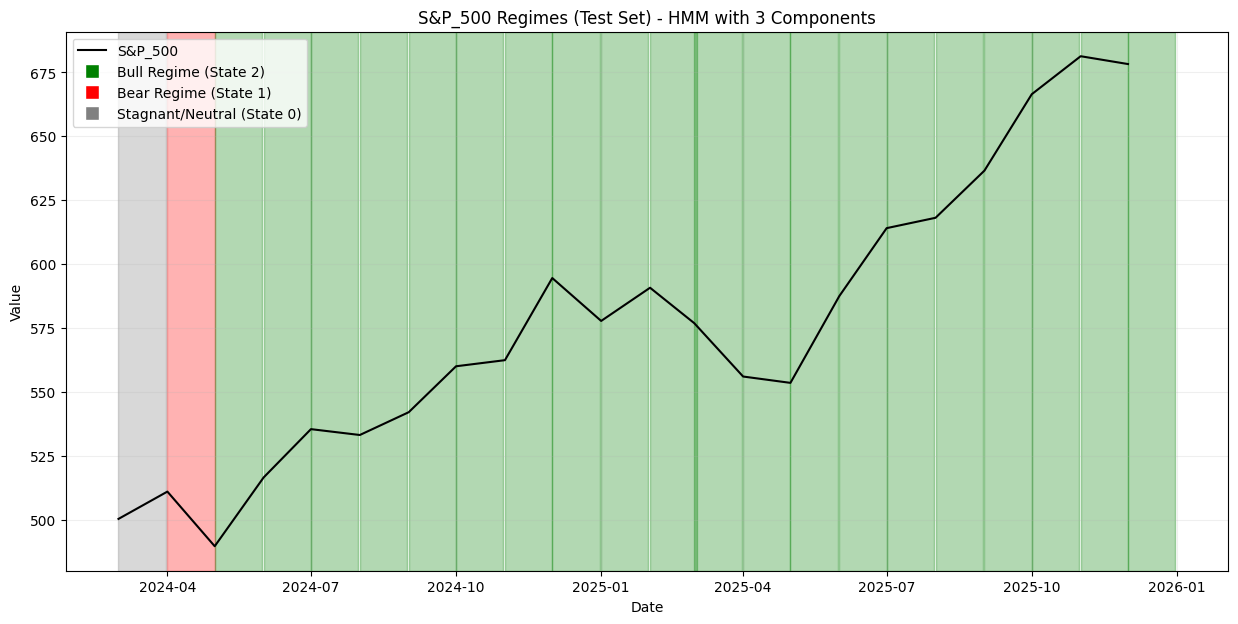

In [ ]:
for column_name in hidden_states_df_test.columns:

    hidden_states_test = hidden_states_df_test[column_name]
    original_series_test = test_data[column_name].iloc[1:]

    # Ensure dates align with hidden states
    dates_for_plot_test = original_series_test.index

    # Retrieve state mapping for this variable
    states_map = hmm_states_mapping.get(column_name, {})
    bear_state = states_map.get('bear_state')
    bull_state = states_map.get('bull_state')
    stagnant_state = states_map.get('stagnant_state')

    plt.figure(figsize=(15, 7))
    plt.plot(dates_for_plot_test, original_series_test, color='black', lw=1.5, label=f'{column_name} Value')

    # Color regime
    for i in range(len(hidden_states_test)):
        if i < len(dates_for_plot_test):
            state = hidden_states_test.iloc[i]
            color = 'green' if state == bull_state else ('red' if state == bear_state else 'gray')

            start_date = dates_for_plot_test[i]
            end_date = dates_for_plot_test[i] + pd.Timedelta(days=30)

            if i == len(dates_for_plot_test) - 1 and len(dates_for_plot_test) > 1:
                end_date = dates_for_plot_test[i] + (dates_for_plot_test[i] - dates_for_plot_test[i-1])

            plt.axvspan(start_date, end_date, color=color, alpha=0.3)

    # Update legend elements to include state indices
    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, label=f'{column_name}'),
        Line2D([0], [0], marker='s', color='w', label=f'Bull Regime (State {bull_state})', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='s', color='w', label=f'Bear Regime (State {bear_state})', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label=f'Stagnant/Neutral (State {stagnant_state})', markerfacecolor='gray', markersize=10)
    ]

    plt.title(f'{column_name} Regimes (Test Set) - HMM with 3 Components')
    plt.ylabel('Value')
    plt.xlabel('Date')
    plt.legend(handles=legend_elements, loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

In [ ]:
# Evaluate on Test Data
test_accuracies, combined_test_results_df = evaluate_pgm_models(
    hidden_states_df_test, target_variable, learned_pgm_models_dict, 'Test'
)
display(combined_test_results_df.head(10))


Evaluating model learned with BIC on Test Data
Accuracy for BIC model on 22 Test predictions: 1.0000

Evaluating model learned with K2 on Test Data
Accuracy for K2 model on 22 Test predictions: 0.5455

Evaluating model learned with BDeu on Test Data
Accuracy for BDeu model on 22 Test predictions: 1.0000

Evaluating model learned with BDs on Test Data
Accuracy for BDs model on 22 Test predictions: 1.0000


,Actual States,Predicted (BIC),Predicted (BDeu),Predicted (BDs),Predicted (K2)
0,1,1,1,1,1
1,0,0,0,0,0
2,1,1,1,1,0
3,0,0,0,0,0
4,1,1,1,1,0
5,0,0,0,0,0
6,1,1,1,1,0
7,0,0,0,0,0
8,1,1,1,1,0
9,0,0,0,0,0


### Test results plots

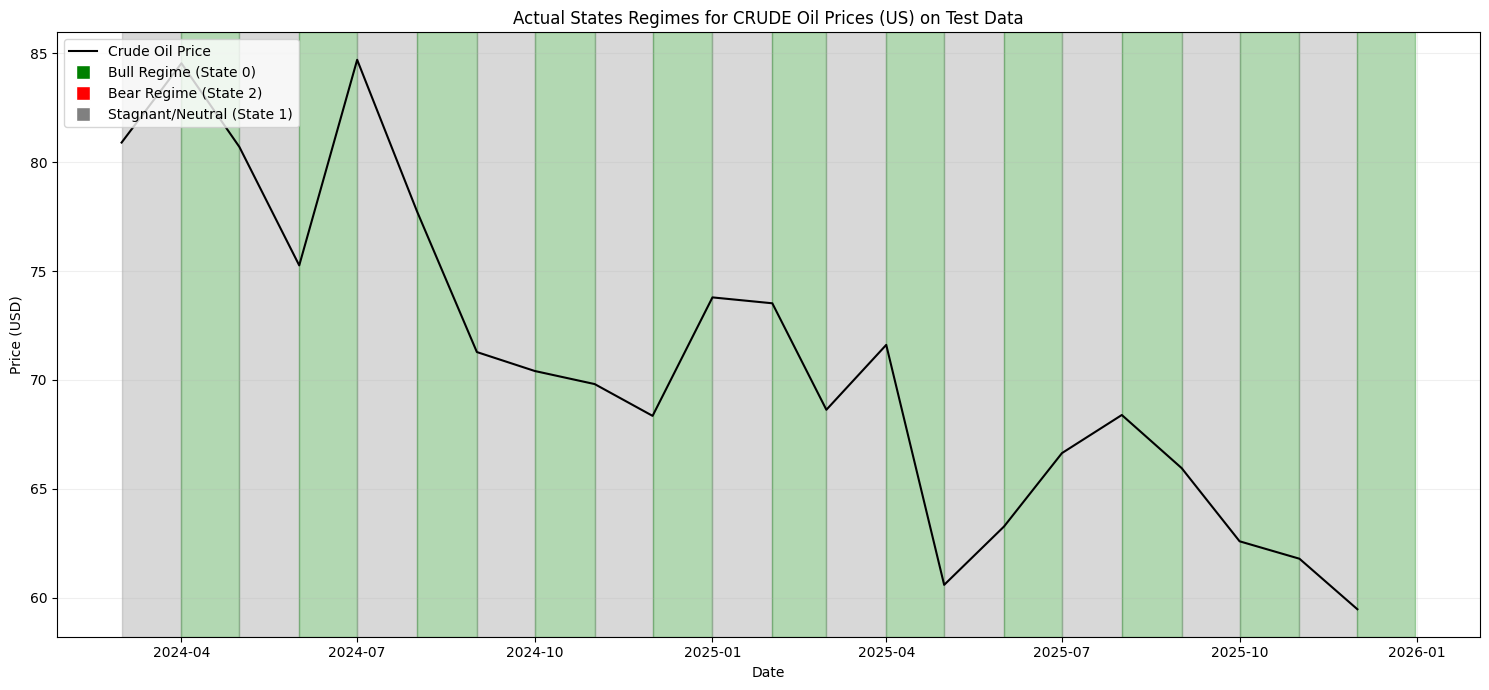

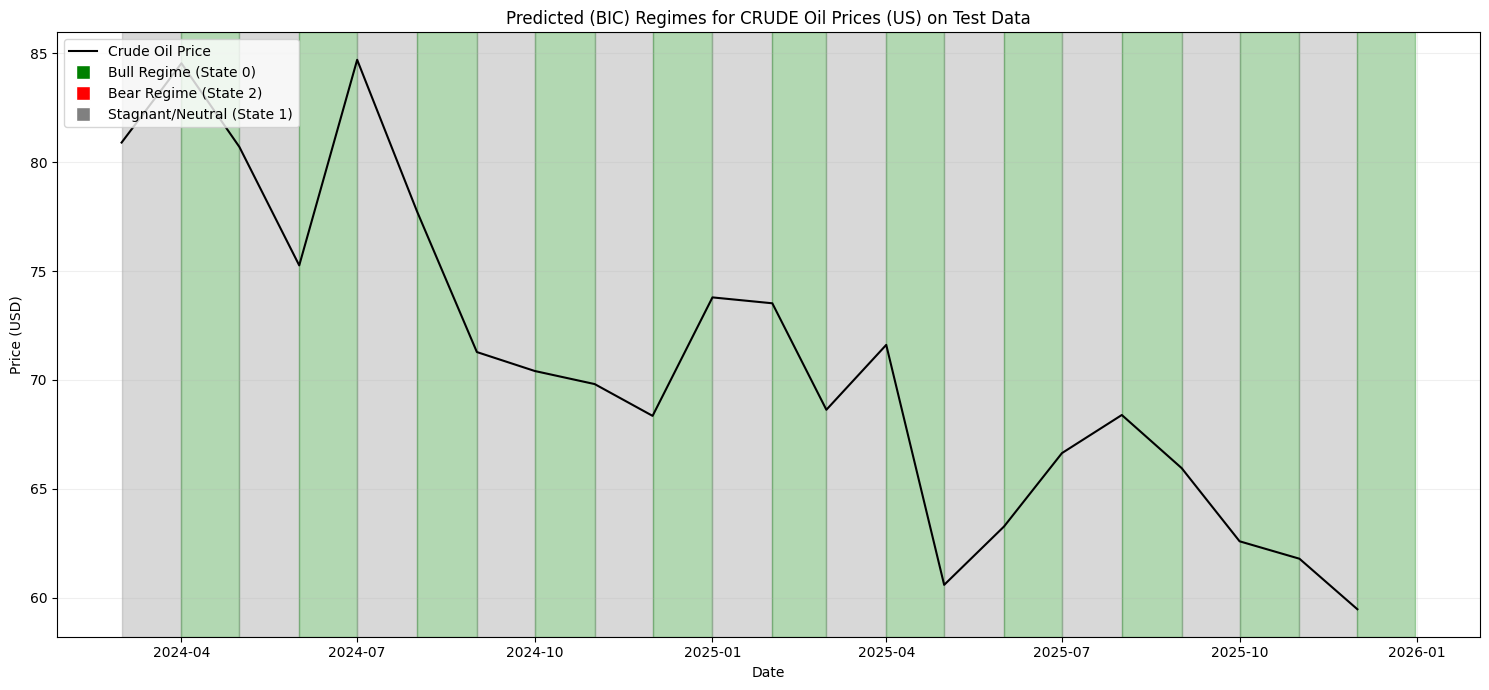

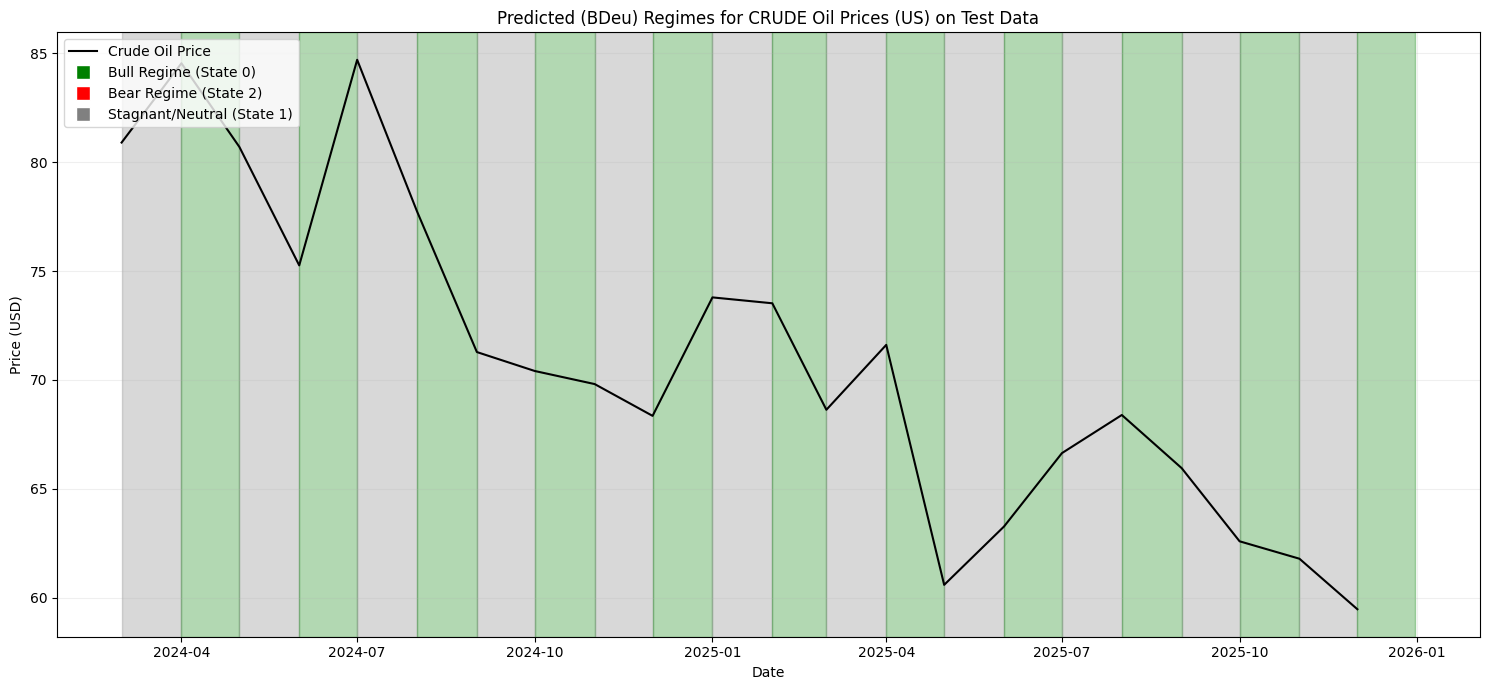

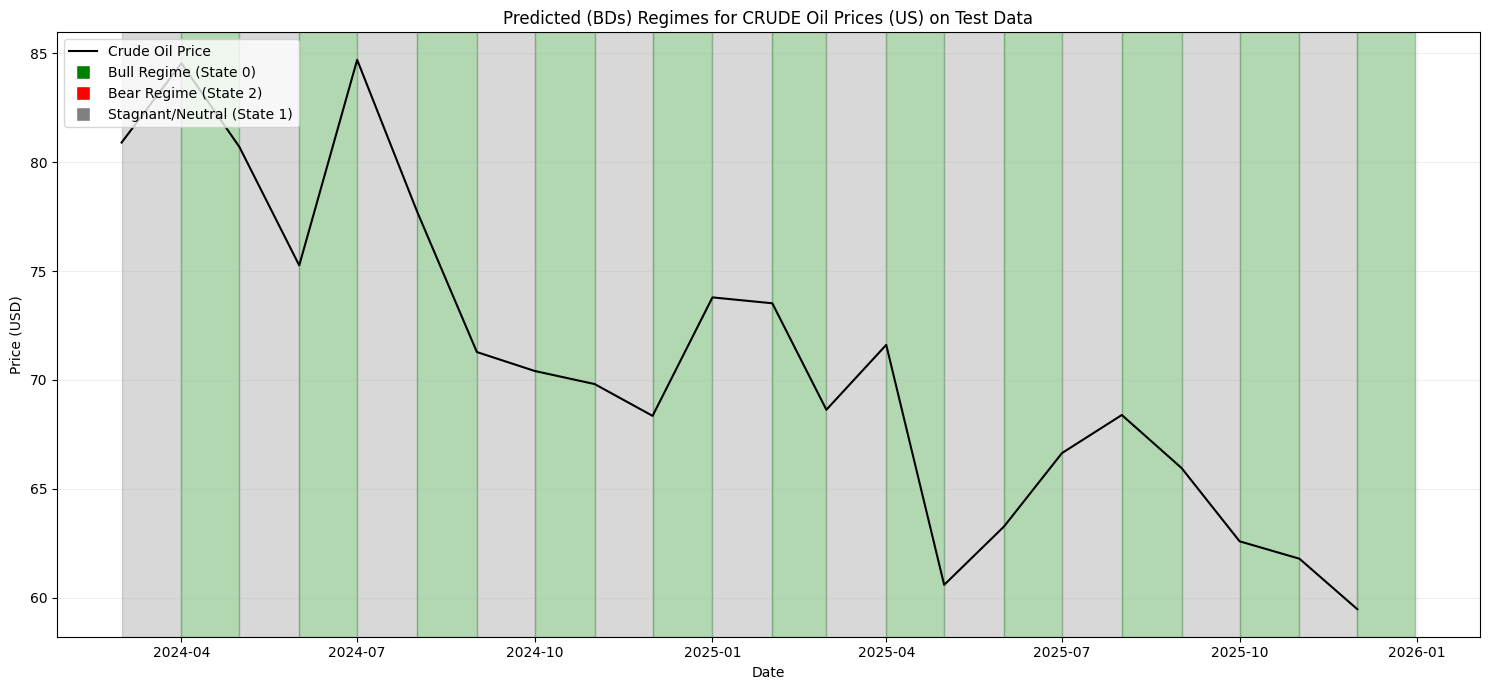

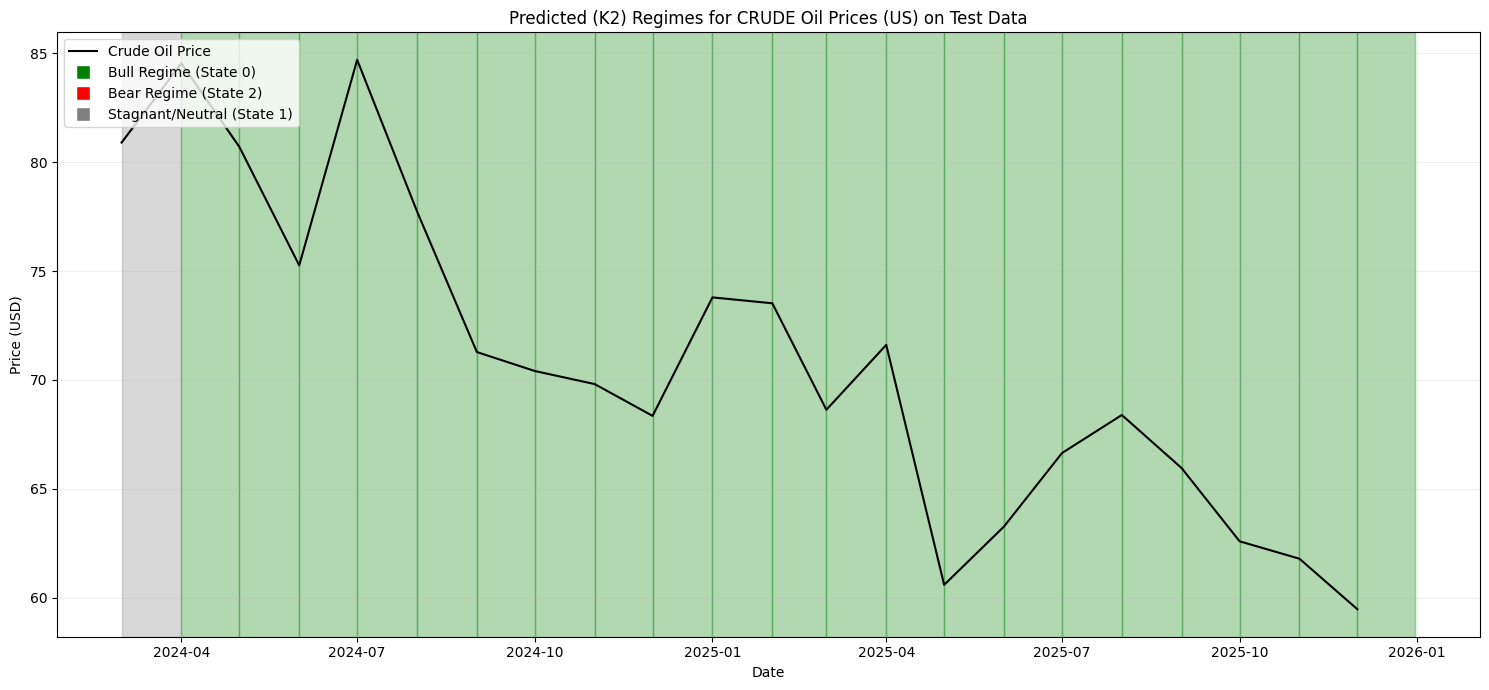

In [ ]:
target_variable_states_map = hmm_states_mapping.get(target_variable, {})
bear_state_idx = target_variable_states_map.get('bear_state')
bull_state_idx = target_variable_states_map.get('bull_state')
stagnant_state_idx = target_variable_states_map.get('stagnant_state')

dates_for_plotting = hidden_states_df_test.index
original_prices = test_data[target_variable].iloc[1:]

for col_name in combined_test_results_df.columns:
    plt.figure(figsize=(15, 7))
    plt.plot(dates_for_plotting, original_prices, color='black', lw=1.5, label='Crude Oil Price')

    current_states = combined_test_results_df[col_name]

    for i in range(len(current_states)):
        state = current_states.iloc[i]
        color = 'green' if state == bull_state_idx else ('red' if state == bear_state_idx else 'gray')

        start_date = dates_for_plotting[i]
        if i < len(dates_for_plotting) - 1:
            end_date = dates_for_plotting[i+1]
        else:
            if len(dates_for_plotting) > 1:
                end_date = dates_for_plotting[i] + (dates_for_plotting[i] - dates_for_plotting[i-1])
            else:
                end_date = dates_for_plotting[i] + pd.Timedelta(days=30)

        plt.axvspan(start_date, end_date, color=color, alpha=0.3)

    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, label='Crude Oil Price'),
        Line2D([0], [0], marker='s', color='w', label=f'Bull Regime (State {bull_state_idx})', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='s', color='w', label=f'Bear Regime (State {bear_state_idx})', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label=f'Stagnant/Neutral (State {stagnant_state_idx})', markerfacecolor='gray', markersize=10)
    ]
    plt.title(f'{col_name} Regimes for CRUDE Oil Prices (US) on Test Data')
    plt.ylabel('Price (USD)')
    plt.xlabel('Date')
    plt.legend(handles=legend_elements, loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

### Test results

In [ ]:
for name, result in test_accuracies.items():
    print(f"\nEvaluation for Model: {name}")
    print("\nClassification Report:")
    print(classification_report(result['actual_states'], result['predicted_states']))


Evaluation for Model: BIC

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        11

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22


Evaluation for Model: K2

Classification Report:
              precision    recall  f1-score   support

           0       0.52      1.00      0.69        11
           1       1.00      0.09      0.17        11

    accuracy                           0.55        22
   macro avg       0.76      0.55      0.43        22
weighted avg       0.76      0.55      0.43        22


Evaluation for Model: BDeu

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        11

    accuracy                 

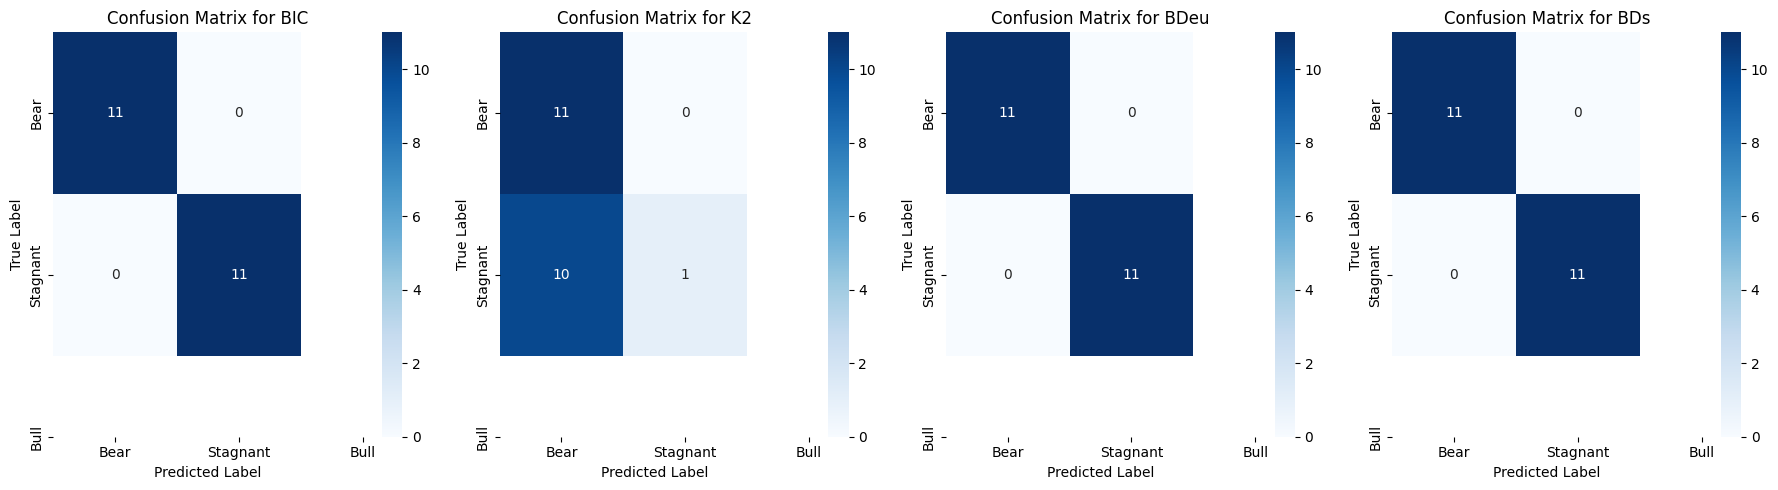

In [ ]:
fig, axes = plt.subplots(1, len(test_accuracies), figsize=(18, 5))
axes = axes.flatten()

for i, (name, result) in enumerate(test_accuracies.items()):
    if not result['actual_states']:
        continue

    cm = confusion_matrix(result['actual_states'], result['predicted_states'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bear', 'Stagnant', 'Bull'],
                yticklabels=['Bear', 'Stagnant', 'Bull'], ax=axes[i])
    axes[i].set_title(f'Confusion Matrix for {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()